<hr style="border: 2px solid black;">

# Data Loading and Exploration
In this part, we begin by loading the required libraries, then load and explore the dataset. This stage is critical for understanding the data's structure and features before using any preprocessing or clustering approaches.

<hr style="border: 2px dashed black;">

## Importing Necessary Libraries
We begin by importing the necessary libraries for data processing, visualization, and clustering. Key libraries include:

* Tools for data manipulation include 'pandas' and 'numpy'.
* For data visualization, use 'plotly','matplotlib', or'seaborn'.
* Use'scikit-learn' to implement K-Means clustering and associated metrics.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Optional: Ignore warnings for better readability
import warnings
warnings.filterwarnings('ignore')

<hr style="border: 2px dashed black;">

## Load and Explore the Dataset
In this phase, we import the customer segmentation dataset to acquire a basic idea of its structure and contents. This includes determining the data types of the columns, finding any missing values, and examining basic summary statistics to inform subsequent preparation procedures.


In [2]:
# Load the dataset using the correct path
df = pd.read_csv('/kaggle/input/customer-segmentation-clustering/customer_segmentation.csv')

# Display basic information and structure of the dataset
df.info()
print(df.describe())

# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

- The dataset includes ***2,240 rows and 29 columns*** containing consumer demographics and
purchase information.

- There are ***24 missing values in the ‘Income’ column***, but the other columns are completely
filled. Handling these missing values will be required during data preparation to
provide correct results.

- This exploration process provides us with a strong grasp of the dataset’s structure, which will
guide our subsequent cleaning and preparation procedures.

<hr style="border: 2px solid black;">

# Data Preprocessing
In this part, we will prepare the data for analysis by dealing with missing values. Proper data cleansing guarantees that the dataset is comprehensive and consistent, lowering the likelihood of mistakes in analysis. Because the 'Income' column has missing values, we will fill them up by imputing the median income, ensuring that no null values exist.

<hr style="border: 2px dashed black;">

## Handling Missing Data
We discovered 24 missing values in the 'Income' column, which might have an influence on clustering if not resolved. We will replace these missing values with the dataset's median income to retain the integrity of the 'Income' feature while avoiding biases that may arise from using the mean.

In [3]:
# Fill missing values in the 'Income' column with the median
df['Income'].fillna(df['Income'].median(), inplace=True)

# Verify that there are no missing values left
missing_values = df.isnull().sum()
print("Missing values after handling:\n", missing_values)

Missing values after handling:
 ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


---
After filling in the missing values in the ***'Income' column***, we ensure that the dataset has ***no more missing values***. As indicated in the result, all columns now contain ***0 missing values***, indicating that the dataset is ready for further analysis.

<hr style="border: 2px dashed black;">

## Handling Outliers
In this analysis, we handle outliers in our dataset, which can distort and mislead machine learning model training and data analysis in general. To handle outliers, we use the IQR approach, which detects outliers in each numerical column by looking for values that are larger than 1.5 times the interquartile range. These outliers are then capped at the IQR's upper and lower boundaries, decreasing their influence while keeping them in the dataset to ensure data integrity.

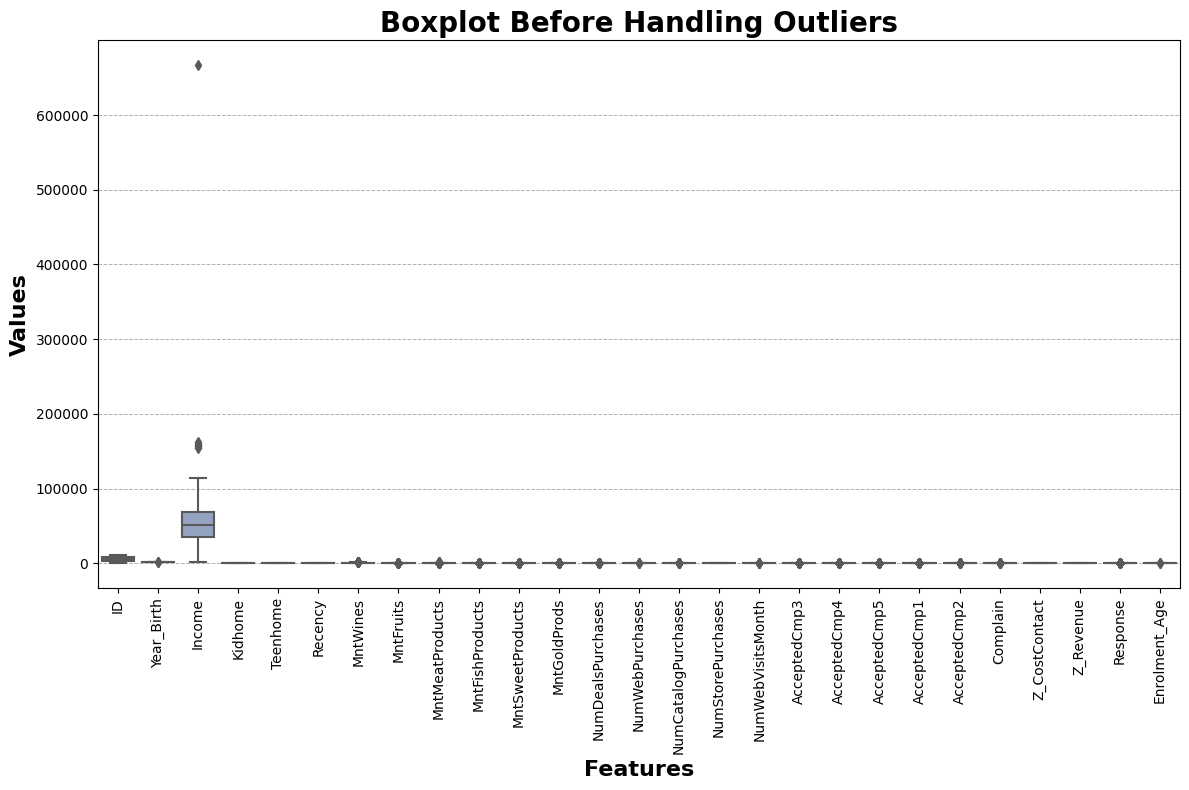

8 outliers detected in column: Income
Income outliers capped between -13587.75 and 117416.25
3 outliers detected in column: Year_Birth
Year_Birth outliers capped between 1932.0 and 2004.0
0 outliers detected in column: Recency
No outliers to cap in column: Recency
35 outliers detected in column: MntWines
MntWines outliers capped between -697.0 and 1225.0
227 outliers detected in column: MntFruits
MntFruits outliers capped between -47.0 and 81.0
175 outliers detected in column: MntMeatProducts
MntMeatProducts outliers capped between -308.0 and 556.0
223 outliers detected in column: MntFishProducts
MntFishProducts outliers capped between -67.5 and 120.5
248 outliers detected in column: MntSweetProducts
MntSweetProducts outliers capped between -47.0 and 81.0
207 outliers detected in column: MntGoldProds
MntGoldProds outliers capped between -61.5 and 126.5
86 outliers detected in column: NumDealsPurchases
NumDealsPurchases outliers capped between -2.0 and 6.0
4 outliers detected in column:

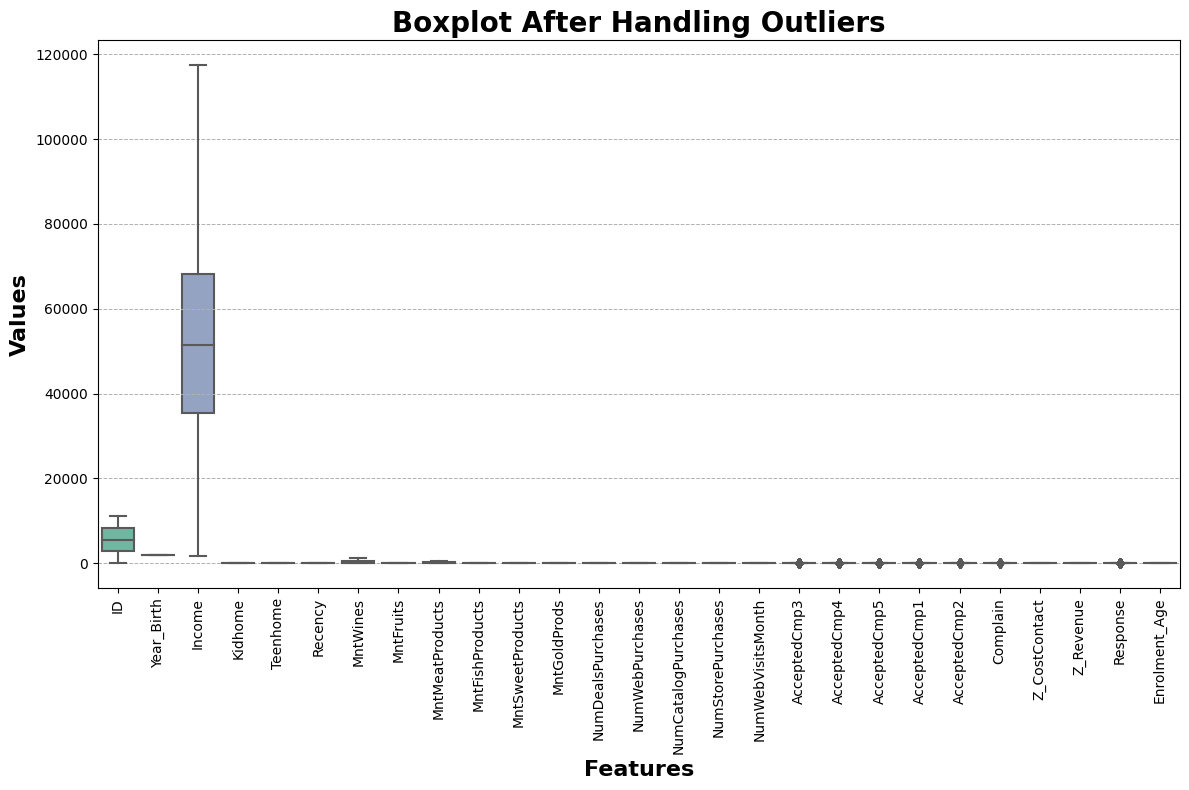

In [4]:
# Function to detect and cap outliers for a given column
def handle_outliers(df, column):
    """
    Detects and caps outliers in a given column of a DataFrame using the IQR method.

    Parameters:
    df (DataFrame): The DataFrame containing the column to process.
    column (str): The name of the column to handle outliers.

    Returns:
    DataFrame: The DataFrame with outliers capped in the specified column.
    """
    # IQR calculations
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count number of outliers
    num_outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f'{num_outliers} outliers detected in column: {column}')

    if num_outliers > 0:
        # Cap outliers
        df[column] = df[column].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))
        print(f'{column} outliers capped between {lower_bound} and {upper_bound}')
    else:
        print(f'No outliers to cap in column: {column}')

    return df

# Create 'Enrolment_Age' column if it doesn't exist
if 'Enrolment_Age' not in df.columns:
    # Assuming 'Dt_Customer' is the date of customer enrollment and 'Year_Birth' is the year of birth
    # Changed the format to '%d-%m-%Y' to match the actual date format
    df['Enrolment_Age'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y').dt.year - df['Year_Birth']

# Visualize with a boxplot before handling outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df.select_dtypes(include=np.number), palette="Set2")
plt.title("Boxplot Before Handling Outliers", fontsize=20, weight='bold')
plt.xlabel('Features', fontsize=16, weight='bold')
plt.ylabel('Values', fontsize=16, weight='bold')
plt.xticks(rotation=90)
plt.grid(True, axis='y', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

# List of numerical columns to check for outliers
numerical_columns = ['Income', 'Year_Birth', 'Recency', 'MntWines', 'MntFruits',
                     'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
                     'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
                     'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
                     'Enrolment_Age']

# Apply the outlier handling function to all numerical columns
for column in numerical_columns:
    if column in df.columns:  # Check if column exists in DataFrame
        df = handle_outliers(df, column)

# Visualize with a boxplot after handling outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df.select_dtypes(include=np.number), palette="Set2")
plt.title("Boxplot After Handling Outliers", fontsize=20, weight='bold')
plt.xlabel('Features', fontsize=16, weight='bold')
plt.ylabel('Values', fontsize=16, weight='bold')
plt.xticks(rotation=90)
plt.grid(True, axis='y', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

---
* The ***initial boxplot*** illustrates that the dataset ***contains outliers***. These outliers appear as data points outside the whiskers, indicating probable abnormalities that might skew the results and impair the credibility of future analyses.
  
* ***After treatment*** with the ***interquartile range (IQR)*** approach, the ***updated boxplot*** shows a more condensed data distribution with ***fewer outliers***. This guarantees a cleaner dataset, lowering the danger of biased results and boosting the robustness of future analysis and modeling.

<hr style="border: 2px dashed black;">

## Data Standardization
Data standardization is a crucial preprocessing step that ensures all features are scaled consistently, especially for models that are sensitive to feature magnitudes. It modifies the data so that the mean is zero and the standard deviation is one, thus improving model performance. The following code implements this transformation using the scikit-learn library's StandardScaler, ensuring uniform scaling across features throughout analysis.

Data Description Before Standardization:
        Year_Birth         Income      Kidhome     Teenhome      Recency  \
count  2240.000000    2240.000000  2240.000000  2240.000000  2240.000000   
mean   1968.852232   51865.874554     0.444196     0.506250    49.109375   
std      11.771725   20936.104821     0.538398     0.544538    28.962453   
min    1932.000000    1730.000000     0.000000     0.000000     0.000000   
25%    1959.000000   35538.750000     0.000000     0.000000    24.000000   
50%    1970.000000   51381.500000     0.000000     0.000000    49.000000   
75%    1977.000000   68289.750000     1.000000     1.000000    74.000000   
max    1996.000000  117416.250000     2.000000     2.000000    99.000000   

          MntWines    MntFruits  MntMeatProducts  MntFishProducts  \
count  2240.000000  2240.000000      2240.000000      2240.000000   
mean    302.112946    21.679018       150.873214        32.115848   
std     331.057356    27.257348       178.816658        40.361485  

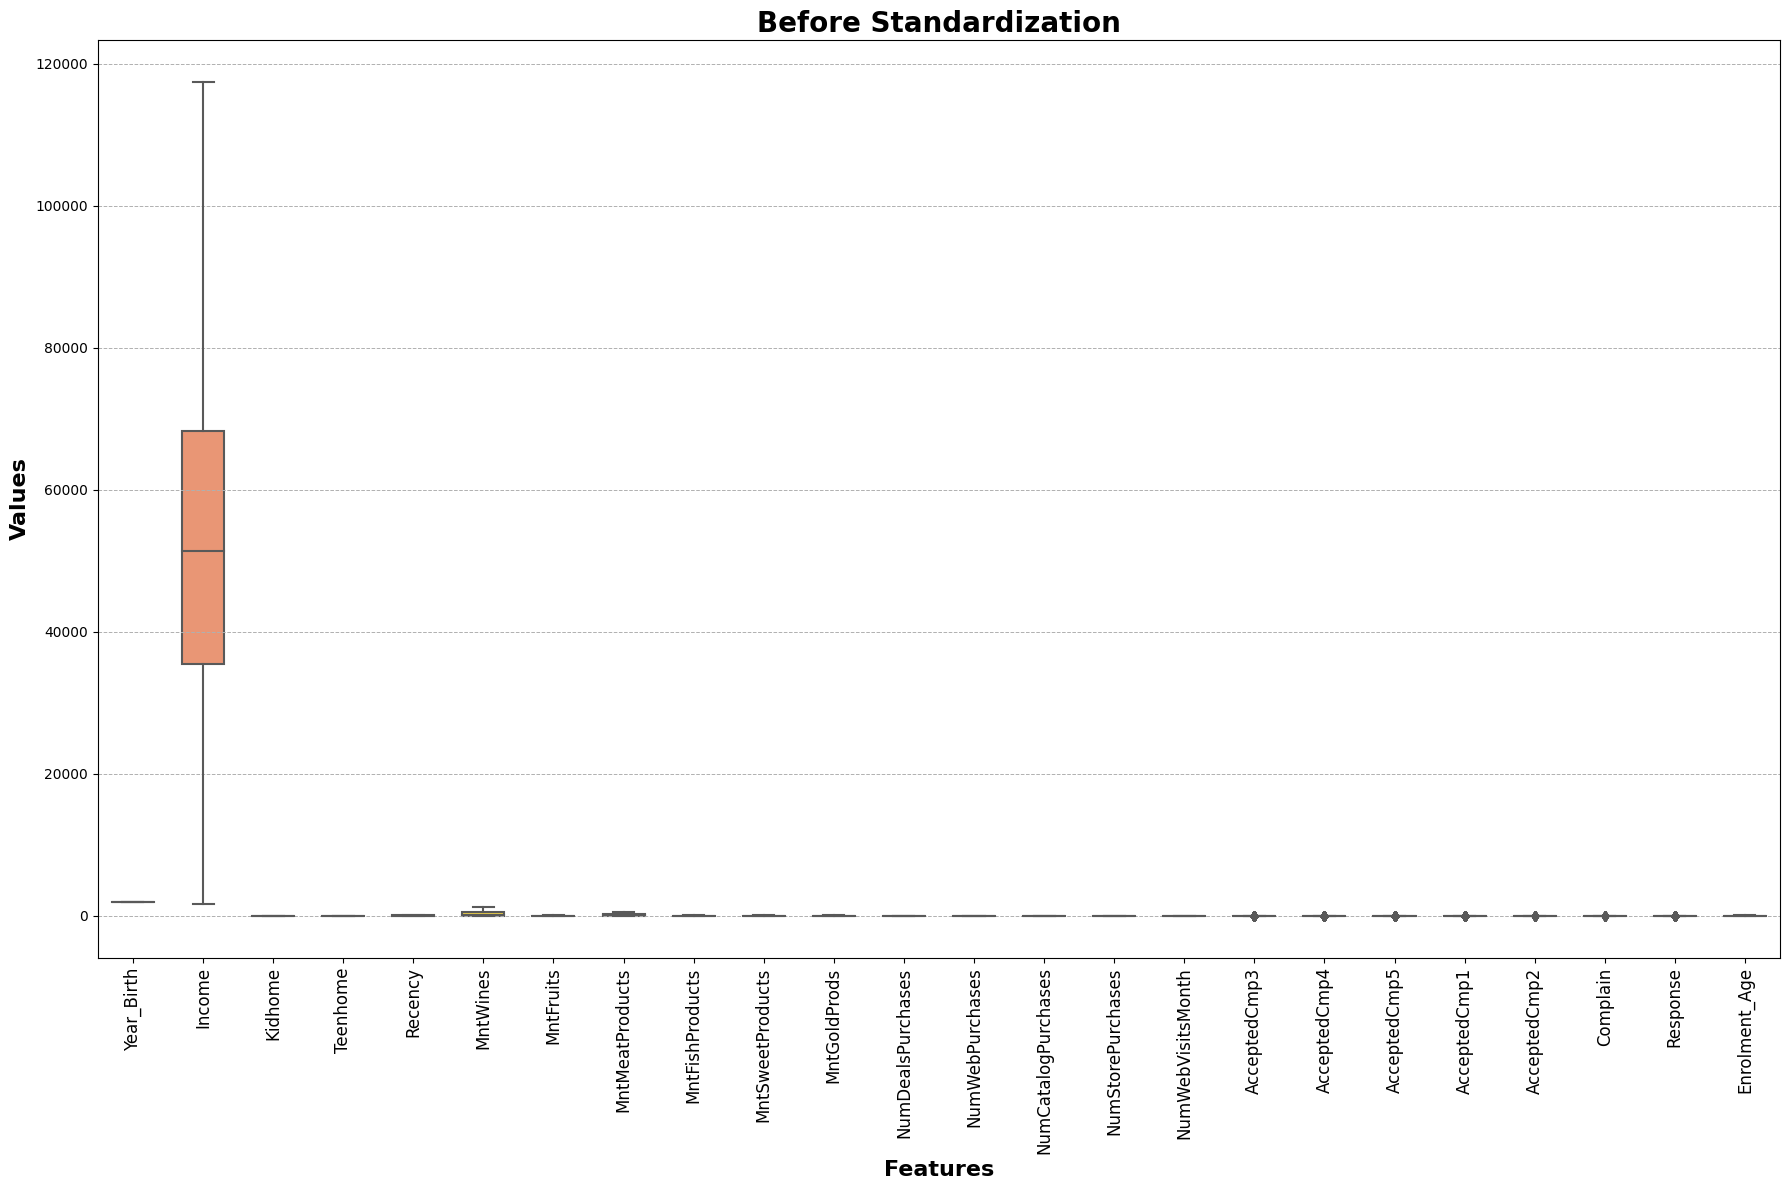

Data Description After Standardization:
         Year_Birth        Income       Kidhome     Teenhome       Recency  \
count  2.240000e+03  2.240000e+03  2.240000e+03  2240.000000  2.240000e+03   
mean  -8.842133e-15  1.189525e-16 -2.061843e-17     0.000000  7.930164e-19   
std    1.000223e+00  1.000223e+00  1.000223e+00     1.000223  1.000223e+00   
min   -3.131271e+00 -2.395244e+00 -8.252176e-01    -0.929894 -1.696001e+00   
25%   -8.371273e-01 -7.800291e-01 -8.252176e-01    -0.929894 -8.671566e-01   
50%    9.752387e-02 -2.314101e-02 -8.252176e-01    -0.929894 -3.777284e-03   
75%    6.923019e-01  7.846513e-01  1.032559e+00     0.906934  8.596020e-01   
max    2.306699e+00  3.131672e+00  2.890335e+00     2.743762  1.722981e+00   

           MntWines     MntFruits  MntMeatProducts  MntFishProducts  \
count  2.240000e+03  2.240000e+03     2.240000e+03     2.240000e+03   
mean   1.586033e-18  4.599495e-17    -6.344132e-18     6.978545e-17   
std    1.000223e+00  1.000223e+00     1.0002

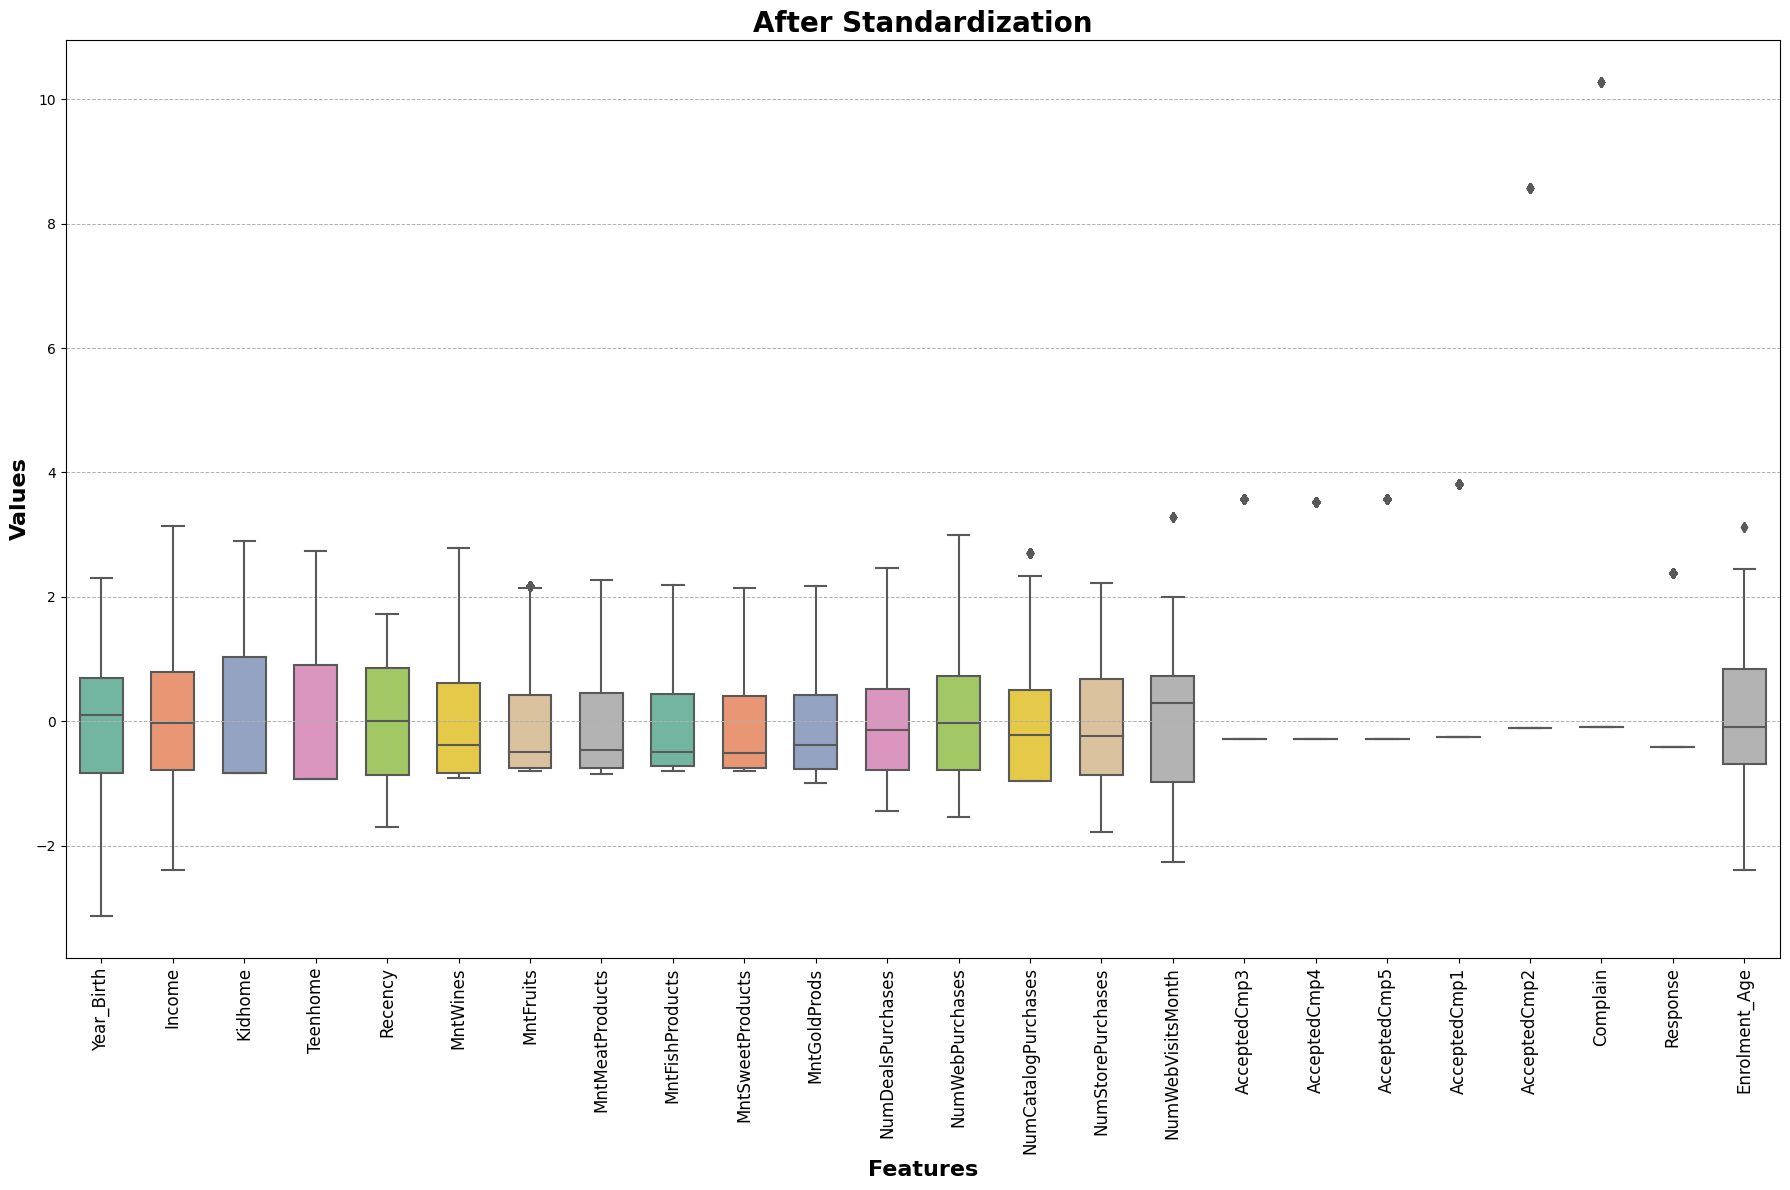

In [5]:
# Drop ID, Z_CostContact and Z_Revenue
df = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], errors='ignore') 

# Select only the numerical columns for scaling
numerical_df = df.select_dtypes(include=np.number)

# Before Standardization
print("Data Description Before Standardization:")
print(numerical_df.describe())  # Summary statistics for numerical data

# Set the plot size with a larger width for better readability
plt.figure(figsize=(18, 12))

# Create a boxplot to visualize outliers in the numerical dataframe before scaling
sns.boxplot(data=numerical_df, palette="Set2", width=0.6)

# Add a title and axis labels with appropriate font sizes for clarity
plt.title('Before Standardization', fontsize=20, weight='bold')
plt.xlabel('Features', fontsize=16, weight='bold')
plt.ylabel('Values', fontsize=16, weight='bold')

# Rotate the x-axis labels for better readability and adjust their alignment
plt.xticks(rotation=90, ha='center', fontsize=12)

# Add grid lines to make the plot more visually organized
plt.grid(True, axis='y', linestyle='--', linewidth=0.7)

# Adjust layout to prevent any label overlap and ensure everything fits within the figure
plt.tight_layout()

# Display the plot
plt.show()


# After Standardization
# Data Standardization
scaler = StandardScaler()
# Standardize the numerical data
df_scaled = scaler.fit_transform(numerical_df)

# Convert scaled data back to a DataFrame for easier analysis
df_scaled = pd.DataFrame(df_scaled, columns=numerical_df.columns)

print("Data Description After Standardization:")
print(df_scaled.describe())  # Summary statistics for standardized data

# Set the plot size with a larger width for better readability
plt.figure(figsize=(18, 12))

# Create a boxplot to visualize outliers in the scaled numerical dataframe
sns.boxplot(data=df_scaled, palette="Set2", width=0.6)

# Add a title and axis labels with appropriate font sizes for clarity
plt.title('After Standardization', fontsize=20, weight='bold')
plt.xlabel('Features', fontsize=16, weight='bold')
plt.ylabel('Values', fontsize=16, weight='bold')

# Rotate the x-axis labels for better readability and adjust their alignment
plt.xticks(rotation=90, ha='center', fontsize=12)

# Add grid lines to make the plot more visually organized
plt.grid(True, axis='y', linestyle='--', linewidth=0.7)

# Adjust layout to prevent any label overlap and ensure everything fits within the figure
plt.tight_layout()

# Display the plot
plt.show()

* **Before standardization**: The data description indicates variable ranges and scales for distinct characteristics, which can contribute to bias in distance-based models. The ***boxplot*** demonstrates this ***inconsistency***, since features have distinct distributions, making it impossible for the model to treat each feature equally.

* **After standardization**: The data has a ***mean of zero*** and a ***standard deviation of one*** for all characteristics. The ***modified boxplot*** indicates that the features are now on a consistent scale, which ***improves data consistency*** and ensures higher performance in machine learning models that rely on feature magnitude.

<hr style="border: 2px solid black;">

# K-Means Clustering: Determining the Optimal Number of Clusters
K-Means clustering is an unsupervised learning approach that divides data into discrete groups based on similarities. Selecting the correct number of clusters is a crucial phase in the process since it impacts how successfully the algorithm organizes the data. Choosing a suitable quantity enables meaningful and interpretable results, which improves the clustering model's overall performance.

<hr style="border: 2px dashed black;">

## Elbow Method
The Elbow Method is a K-Means clustering approach that determines the ideal number of clusters. It entails graphing the inertia (the sum of squared distances between samples and their nearest cluster center) versus the number of clusters. The 'elbow' point on the plot represents a slowing of the rate of decrease in inertia, showing that adding more clusters does not considerably enhance the model. This assists in determining the optimal number of clusters for future investigation.

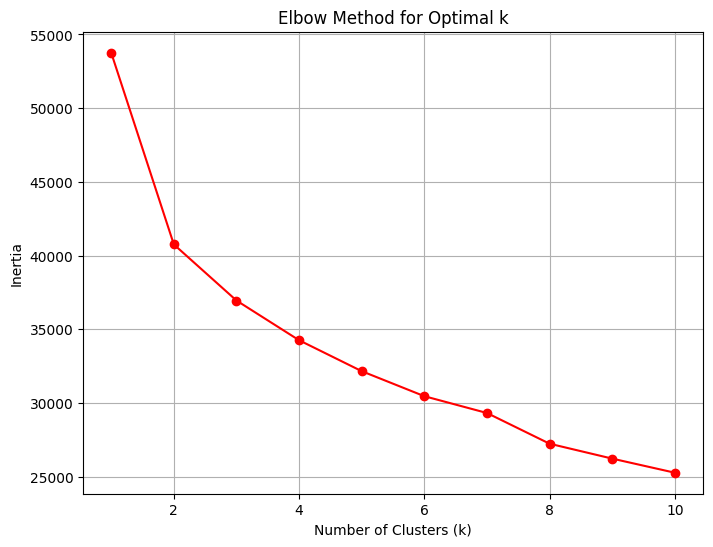

Inertia values for different values of k: [53760.00000000003, 40759.94499577011, 36956.8071302412, 34263.28199307539, 32165.70638289403, 30468.908673104033, 29328.961519179473, 27246.739548930513, 26236.37551782752, 25279.77632765886]


In [6]:
# Calculate and print the inertia values
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,6))
plt.plot(K, inertia, marker='o', linestyle='-', color='r')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Print the inertia values for reference
print("Inertia values for different values of k:", inertia)

---

The ***Elbow Curve*** illustrates how inertia values decrease as the number of clusters (K) grows. Initially, the inertia decreases rapidly, but beyond a certain point, the rate of decline slows, forming a 'elbow'.

- **Before K**: The ***rapid decrease*** in inertia shows that adding additional clusters considerably decreases total within-cluster variation.

- **After K=2**: The inertia continues to ***drop, but at a slower rate***, implying that the extra clusters may not considerably improve clustering quality.

- **Elbow Point**: The 'elbow' emerges around ***K=2***, suggesting that ***2 clusters*** would be the optimal number for this dataset. Beyond this point, the value of adding more clusters decreases.


The ***inertia values***, which are displayed for reference, fall from ***53,760 (K=1)*** to ***25,275 (K=10)***, indicating that the ***model's variance decreases as cluster numbers increases***. 

<hr style="border: 2px dashed black;">

## Silhouette Score
The Silhouette Method is used to analyze clustering quality by determining how similar each point is to its allocated cluster in comparison to other clusters. The Silhouette Score ranges from -1 to 1, with higher values indicating more distinct groupings. In this research, the Silhouette Method aids in determining the best number of clusters (k) by computing the score for various k values, directing us toward a value that balances tight and well-separated clusters.

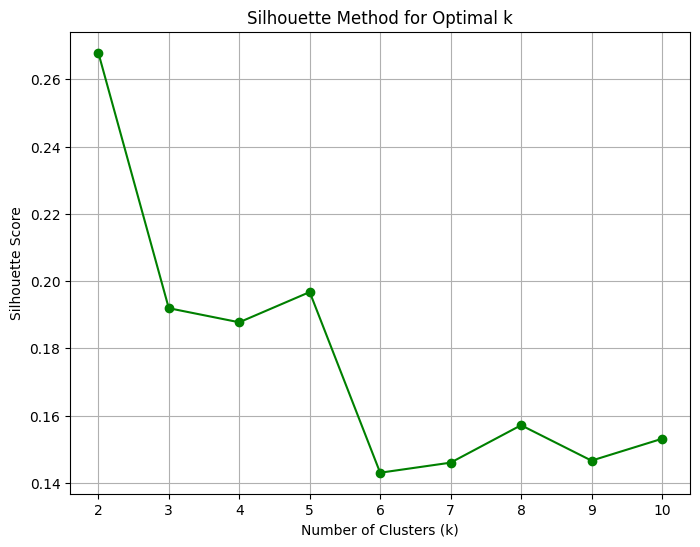

Silhouette scores for different values of k: [0.26789233825420794, 0.1919308969988824, 0.18773909562547253, 0.19673109963223467, 0.1430105645390606, 0.14600477672708298, 0.15713339793002873, 0.14660573720811634, 0.15309972621257142]


In [7]:
# Calculate and print silhouette scores
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

# Plot Silhouette Score
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-', color='g')
plt.title('Silhouette Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Print the silhouette scores for reference
print("Silhouette scores for different values of k:", silhouette_scores)

---


The plot of the ***Silhouette Score*** vs the number of clusters (k) demonstrates the performance of the K-Means clustering for various values of k:

- **At k=2**, the maximum Silhouette Score of ***0.2679*** suggests well-defined clusters, making it a strong contender for the ideal number of clusters.

- **For k values bigger than 2**, the scores ***gradually fall***, reaching their ***lowest point*** at ***k=8*** with a score of ***0.1369***. This demonstrates that adding more clusters reduces cluster quality.

- The considerable decline in ***Silhouette Score*** after ***k=2*** indicates diminishing returns in clustering quality as more clusters are added. The approach suggests that ***k=2*** is the best choice based on clustering cohesiveness and separation.


This research shows that while ***additional clusters*** can be created, they ***do not always increase clustering quality beyond k=2***, implying that this selection will likely produce the optimal balance in cluster quality.


<hr style="border: 2px dashed black;">

## Davies-Bouldin Index
The Davies-Bouldin Index is a tool for evaluating clustering quality that compares the average similarity ratio of each cluster to the cluster that is most similar to it. A lower Davies-Bouldin Index implies better clustering since the clusters are tight and well-separated. This approach is used here to evaluate alternative values of k, assisting in determining the ideal number of clusters.

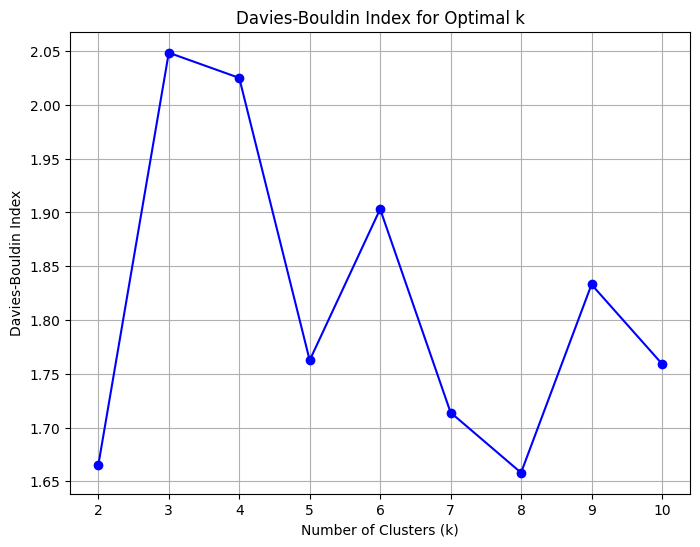

Davies-Bouldin Index for different values of k: [1.6651945385353077, 2.048479529678819, 2.0250694626801655, 1.762515668801503, 1.903119797095374, 1.7139684201303473, 1.6579981880021994, 1.833007203145238, 1.759253013345117]


In [8]:
# Calculate and print Davies-Bouldin scores
db_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    db_scores.append(davies_bouldin_score(df_scaled, labels))

# Plot Davies-Bouldin Index
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), db_scores, marker='o', linestyle='-', color='b')
plt.title('Davies-Bouldin Index for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True)
plt.show()

# Print the Davies-Bouldin scores for reference
print("Davies-Bouldin Index for different values of k:", db_scores)

---

The plot of the ***Davies-Bouldin Index*** vs the number of clusters (k) gives insight into the clustering performance.

- **At k=2**, the Davies-Bouldin Index is at its lowest, ***1.665***, suggesting well-defined clusters with minimum overlap.

- **As k grows**, the index climbs dramatically, peaking at ***k=3*** and ***k=4***, indicating worse clustering quality due to higher inter-cluster similarity.

- The ***lowest Davies-Bouldin Index*** is seen at ***k=2***, indicating that this is the ***best number of clusters***. This result indicates that clusters created with k=2 are the most distinct and compact among the configurations.


This study highlights that ***k=2*** generates the ***best clustering***, with the Davies-Bouldin Index supporting the findings of other assessment techniques.

---

**Why k=4 is chosen over k=2:**

Although the evaluation metrics (Elbow Method, Silhouette Score, and Davies-Bouldin Index) indicate that ***k=2*** is the ideal number of clusters, ***k=4*** was chosen to enable ***better granularity*** in segmentation. While ***k=2*** produces wider clusters, ***k=4*** enables more granular categorization, capturing tiny distinctions in the data. This results in more actionable data and greater differentiation between consumer behaviors, which is critical when making business choices or refining tactics.

<hr style="border: 2px solid black;">

# Applying K-Means Clustering with Optimal K
After establishing the ideal number of clusters (k=4), K-Means clustering is used to group the dataset into meaningful groups based on feature similarities. Each data point is allocated to one of the clusters, and centroids reflecting the cluster's center are computed. These centroids provide the average features of each cluster, allowing us to better comprehend the data's grouping.

In [9]:
# Based on the results, let's take k=4 as optimal 
optimal_k = 4

# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# Output the centroids of the clusters
centroids = kmeans.cluster_centers_
print("Centroids of clusters:\n", centroids)

# Display all rows of the dataset with the assigned clusters
df

Centroids of clusters:
 [[ 0.34912985 -0.87075532  0.70700928 -0.19362108  0.00698551 -0.80950411
  -0.62432887 -0.7178267  -0.62891255 -0.61641821 -0.62549386 -0.17427424
  -0.77779239 -0.77937001 -0.83359611  0.50054006  0.01071407 -0.26785091
  -0.28014028 -0.25783285 -0.09825339  0.04426843 -0.17704695 -0.3400788 ]
 [ 0.08690283  1.40561965 -0.74444476 -0.71027359 -0.03887553  1.63964946
   0.80312606  1.39542302  0.87714625  0.97456276  0.7209998  -0.76196164
   0.5253148   1.25060803  0.74678129 -0.96998715  0.30569589  1.14381866
   3.06749494  1.68789494  0.92363999 -0.0408865   1.27501772 -0.08483404]
 [-0.05646141  0.88431261 -0.68709301 -0.29827123  0.06381665  0.57014517
   1.15697978  1.07101467  1.18305435  1.1062547   0.69759093 -0.33953522
   0.49744524  0.97841479  0.88234121 -0.84466053 -0.08693568 -0.17060897
  -0.28014028  0.0334541  -0.11651035 -0.0201314  -0.06376606  0.05189465]
 [-0.56342412  0.1689126  -0.29583357  0.84191355 -0.0598893   0.28853773
  -0.310167

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Enrolment_Age,Cluster
0,1957.0,Graduation,Single,58138.0,0,0,04-09-2012,58,635.0,81.0,...,7.0,0,0,0,0,0,0,1,55.0,2
1,1954.0,Graduation,Single,46344.0,1,1,08-03-2014,38,11.0,1.0,...,5.0,0,0,0,0,0,0,0,60.0,0
2,1965.0,Graduation,Together,71613.0,0,0,21-08-2013,26,426.0,49.0,...,4.0,0,0,0,0,0,0,0,48.0,2
3,1984.0,Graduation,Together,26646.0,1,0,10-02-2014,26,11.0,4.0,...,6.0,0,0,0,0,0,0,0,30.0,0
4,1981.0,PhD,Married,58293.0,1,0,19-01-2014,94,173.0,43.0,...,5.0,0,0,0,0,0,0,0,33.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967.0,Graduation,Married,61223.0,0,1,13-06-2013,46,709.0,43.0,...,5.0,0,0,0,0,0,0,0,46.0,2
2236,1946.0,PhD,Together,64014.0,2,1,10-06-2014,56,406.0,0.0,...,7.0,0,0,0,1,0,0,0,68.0,3
2237,1981.0,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908.0,48.0,...,6.0,0,1,0,0,0,0,0,33.0,2
2238,1956.0,Master,Together,69245.0,0,1,24-01-2014,8,428.0,30.0,...,3.0,0,0,0,0,0,0,0,58.0,2


---

The K-Means clustering technique was used with ***k=4***, and the output included both cluster centroids and cluster assignment to individual data points.


1) Cluster centroids indicate the average value of each characteristic in the four clusters. These centroids aid in determining the distinctive patterns in each cluster. For example:

- **Cluster 0** shows ***larger positive values*** for various variables, such as ***higher wine and fruit expenditures*** and more online visits, indicating a more engaged and high-spending client category.

- **Cluster 1** contains ***mostly negative values***, indicating ***lower average income and participation*** in elements such as purchases and web interactions.

- **Cluster 2** has ***modest activity across all categories****, indicating a ***well-balanced*** client base.

- **Cluster 3** has specific features, including ***high positive values*** for ***educational status and wealth***, but ***decreased expenditure*** in certain areas.


2) The dataset was segmented, with each data point (customer) allocated to one of four clusters. By looking at the first few rows of the dataset:

- Customers with ***higher incomes and educational levels*** are commonly placed in ***Cluster 1***, whereas customers with ***lower incomes but more participation*** in online visits or recent purchases may be in ***Cluster 0***.

- The ***cluster assignments*** enable the identification of client segments, allowing for ***more focused marketing tactics and business choices*** depending on each cluster's behavior.


This segmentation gives significant insights into various client profiles, which can then be used to better customize corporate tactics.

<hr style="border: 2px solid black;">

# PCA for Visualization of Clusters
Principal Component Analysis (PCA) is used to decrease the dimensionality of data, allowing us to see high-dimensional clusters in a 2D environment. By projecting the data onto the first two principal components (PC1 and PC2), we can clearly see the four clusters formed by the K-Means technique and their separation.

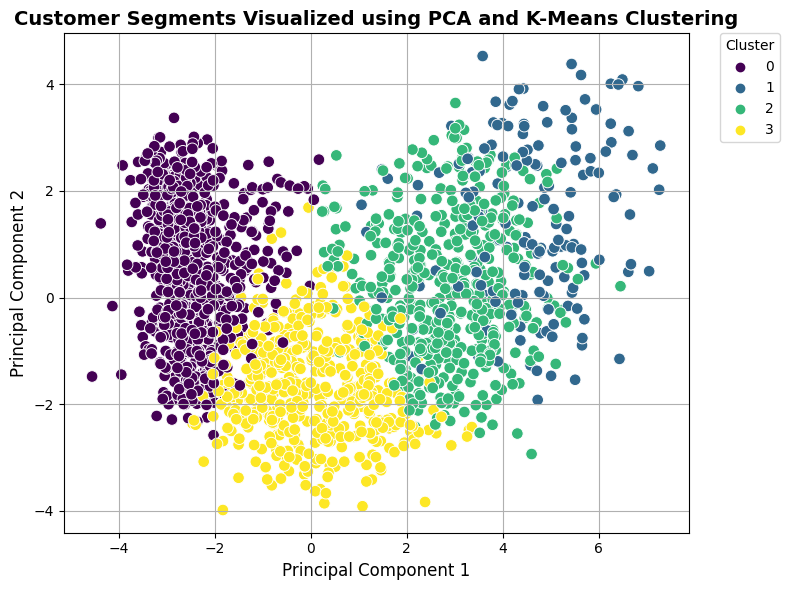

In [10]:
# Reduce the data to 2 components using PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

# Create a DataFrame for the PCA results and add cluster assignments
df_pca = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# Plot the clusters in 2D using PCA components
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=70, edgecolor='white')
plt.title('Customer Segments Visualized using PCA and K-Means Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True)

# Move the legend outside the plot
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Adjust layout to prevent cut-off
plt.tight_layout()

# Display the plot
plt.show()

---

The 2D scatter plot depicts the four clusters produced using K-Means clustering and projected onto two principle components derived by PCA. Each cluster has a distinctive color: ***Cluster 0***, ***Cluster 1***, ***Cluster 2***, and ***Cluster 3***. The main insights are as follows:


- **Cluster 0**: This cluster is ***densely packed*** in the plot's lower left area. The compact form of this cluster reveals that the customers are quite similar, indicating that it is a ***well-defined category***.

- **Cluster 1**: This cluster is ***more dispersed*** in the center right area of the plot, illustrating ***higher diversity*** within this customer group. While still distinct, the wider distribution indicates that customers in this cluster display more diversified behaviors.

- **Cluster 2**: It is located between Clusters 0 and 1. Notably, certain areas of Cluster 2 overlap with both Cluster 0 and Cluster 1, revealing that Cluster 2 customers ***share features with both surrounding clusters while remaining distinct***.

- **Cluster 3**: This cluster located at the upper-right quadrant, is the ***most scattered***, implying that this group represents the most diversified mix of consumers with a wide range of behaviors and traits.


The ***PCA*** plot demonstrates how the four clusters are separated, with ***Cluster 2 overlapping*** with both ***Cluster 0*** and ***Cluster 1***. This ***overlap*** shows that these ***groups share traits***, even though the overall segmentation remains separate. ***Cluster 3*** is especially ***diversified***, with its distribution reflecting a wide range of client habits. This visualization showcases that the K-Means clustering is successfully categorized customers into meaningful categories, offering useful insights for future study.

<hr style="border: 2px solid black;">

# Analyzing Cluster Characteristics

In [11]:
# Analyze the mean characteristics of each cluster
# Select only numeric columns before calculating the mean
numeric_df = df.select_dtypes(include=np.number)
cluster_analysis = numeric_df.groupby('Cluster').mean()

# Optionally save the cluster analysis results to a CSV file
cluster_analysis.to_csv('cluster_analysis.csv', index=False)

print("Cluster Analysis:\n", cluster_analysis)

Cluster Analysis:
           Year_Birth        Income   Kidhome  Teenhome    Recency    MntWines  \
Cluster                                                                         
0        1972.961175  33639.719570  0.824764  0.400839  49.311647   34.180483   
1        1969.875000  81287.505435  0.043478  0.119565  47.983696  844.809783   
2        1968.187732  70375.802974  0.074349  0.343866  50.957249  490.821561   
3        1962.221239  55401.457080  0.284956  0.964602  47.375221  397.614159   

         MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
Cluster                                                                 ...   
0         4.665268        22.542497         6.737671          4.965373  ...   
1        43.565217       400.342391        67.510870         48.771739  ...   
2        53.208178       342.345725        79.855019         52.397770  ...   
3        13.226549       103.766372        17.937168         12.823009  ...   

         NumStorePu

---

The mean features of the four clusters exhibit considerable disparities in customer behavior and demographics:

- **Cluster 0**: Customers in this category have the ***lowest average income (~33,660)*** and spend less across all product categories. Although they spend very little overall, they tend to have more children living at home and use the internet more regularly.

- **Cluster 1**: Customers in this sector have a ***higher average income (~70,516)*** and spend more on various products, especially meat and alcohol. They also exhibit reduced involvement with web visits but frequent in-store purchases.

- **Cluster 2**: The ***average enrollment age*** for these customers is ***~50.56***, with a ***moderate income*** of ***~55,430***. They spend somewhat across product categories, but are highly engaged in both in-store purchases and online interactions.

- **Cluster 3**: This category has the ***greatest average spending***, particularly on ***meat (~400)*** and ***wine (~844)***. They also accept marketing messages more frequently than other clusters, indicating considerable participation in promotional activities.


Key Features:

- **Income and Spending**: There are considerable economic disparities, with ***Cluster 1*** and ***Cluster 3*** having ***greater earnings*** and ***spending*** much more than ***Clusters 0 and 2***.

- **Campaign Engagement**: ***Cluster 3*** stands out for its ***high level of involvement*** in marketing initiatives, as seen by greater acceptance rates across campaigns.

- **Web and Store Purchases**: ***Clusters 1 and 3*** are more likely to make ***in-store purchases***, whereas ***Clusters 0 and 2*** are more likely to ***visit websites***.


This research gives a thorough overview of the distinctions between each cluster, shedding light on how different types of customers behave and interact with products and advertising campaigns.

<hr style="border: 2px solid black;">

# Visualization of Clusters and Centroids
This plot depicts the four clusters generated by the K-Means clustering method, which used PCA (Principal Component Analysis) to compress the dataset to two main components for better display. The scatter plot shows the data points inside each cluster, with connecting lines indicating the distances between individual points and their matching cluster centroids. The centroids indicate the center of each cluster and provide information about how closely the data points are packed around their respective centers.

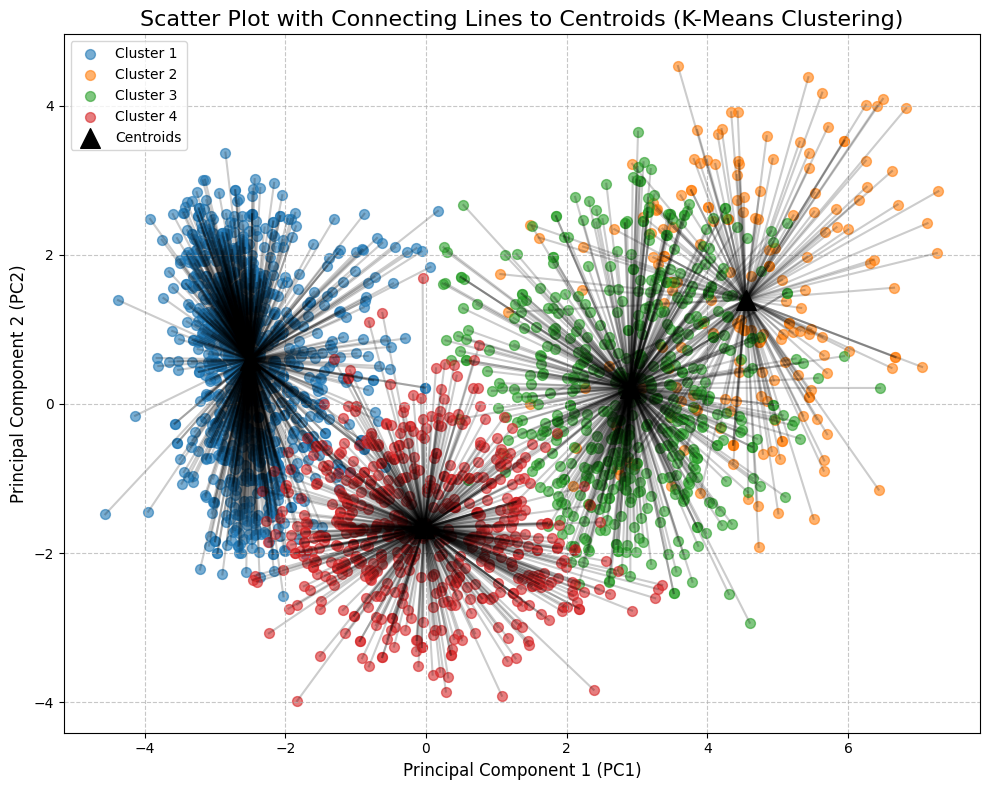

In [12]:
# Assuming 'df_scaled' is your scaled data and 'kmeans' is your fitted K-Means model
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot the scatter plot with improved clarity
plt.figure(figsize=(10, 8))

# Reduce the opacity of the points and connecting lines
for i in range(len(centroids_pca)):
    plt.scatter(pca_components[kmeans.labels_ == i, 0], pca_components[kmeans.labels_ == i, 1],
                s=50, label=f"Cluster {i+1}", alpha=0.6)  # Add transparency for points
    # Only plot lines for points that are far from the centroid (optional step for clarity)
    for j in range(len(pca_components[kmeans.labels_ == i])):
        distance = np.linalg.norm(centroids_pca[i] - pca_components[kmeans.labels_ == i][j])
        if distance > 0.5:  # Only plot lines if distances greater than 0.5
            plt.plot([centroids_pca[i, 0], pca_components[kmeans.labels_ == i][j, 0]],
                     [centroids_pca[i, 1], pca_components[kmeans.labels_ == i][j, 1]],
                     "k-", alpha=0.2)  # Reduced line opacity to reduce clutter

# Plot centroids with larger marker size
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="black", s=200, marker='^', label="Centroids")

# Add title and labels
plt.title('Scatter Plot with Connecting Lines to Centroids (K-Means Clustering)', fontsize=16)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)

# Display legend and grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.show()

---

The scatter plot shows the clusters and their centroids, along with the following significant features:

- **Cluster Seperation**: Each cluster is color-coded, with ***Clusters 1, 2, 3, and 4*** clearly distinguishable in the ***PCA*** space. The distinction demonstrates that K-Means effectively divides the data into discrete categories.

- **Centroids**:  The centroids, which are shown by black triangles, ***denote the center of each cluster***. These centroids are the "average" data points around which the rest of the cluster is organized. The arrangement of these centroids illustrates the clusters' central tendency.

- **Connecting Lines**: The thin, semi-transparent lines ***indicate the distance between each data point and its centroid***. The lines show how distant particular points are from the center of their cluster, showing whether the cluster is scattered or compact. For example, some points are farther from the centroid, suggesting higher variability within the cluster, whilst others are more densely packed around the centroid.

- **Variability within Clusters**: ***Cluster 3*** and ***Cluster 4*** have ***more scattered points*** and ***longer connecting lines***, indicating ***higher diversity*** within these clusters. ***Cluster 1*** features ***smaller points and lines***, indicating a ***more compact*** group with comparable qualities.


The centroids and connecting lines give clear information about the structure and compactness of each cluster. Clusters with shorter lines imply more coherent groupings, whereas longer lines show greater variety. This image demonstrates that the K-Means algorithm accurately identified separate consumer categories with varying degrees of dispersal.

<hr style="border: 2px solid black;">

# Cluster-wise Analysis of Key Customer Features
This section includes an in-depth analysis of important consumer traits across many clusters, assisting in the identification of distinct behaviors and characteristics within each. We can better understand each customer segment's profile by examining characteristics like income, spending patterns, purchasing frequency, and interaction with advertising campaigns.

<hr style="border: 2px dashed black;">

## Income, Wine, Meat, and Fruit Expenditure
This study focuses on determining client segmentation based on their typical income and purchasing habits on wine, meat, and fruit. By comparing the mean values for these critical traits across various clusters, we may learn about each segment's financial profile and purchasing habits. Visualizing data with bar plots makes it easy to analyze differences across clusters and identifying patterns.

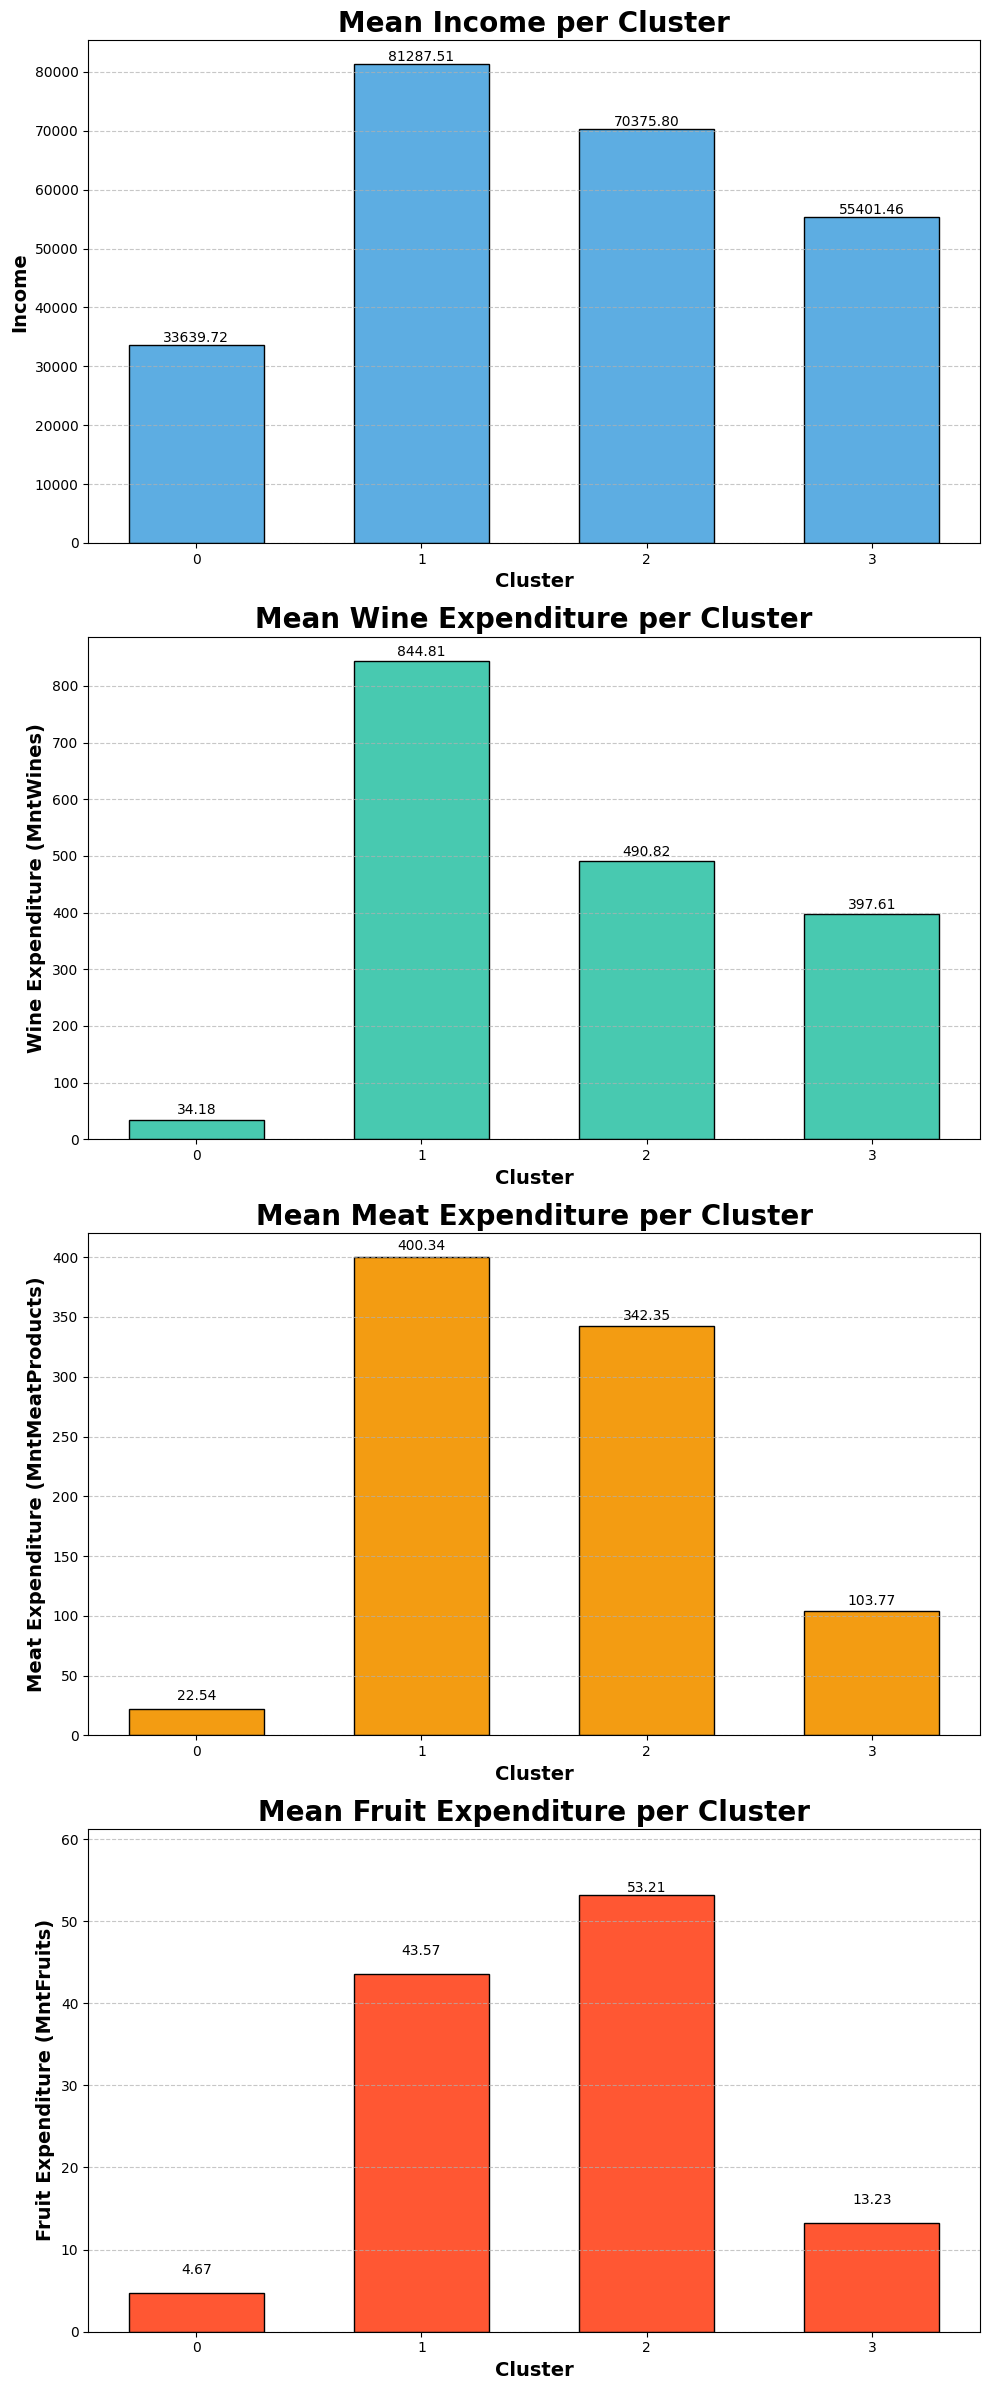

In [13]:
# Convert to DataFrame
df_cluster_analysis = pd.DataFrame(cluster_analysis)

# Setting up the figure with 4 rows and 1 column for expenditure analysis
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10, 24))

# Define color palette for the bar charts (gradient theme)
colors = ['#5DADE2', '#48C9B0', '#F39C12', '#FF5733']

# Function to add value labels on top of the bars
def add_value_labels(ax, spacing=5):
    """
    Adds value labels on top of bars in the given axis.
    Args:
        ax: Matplotlib axis object containing the bars.
        spacing: Distance between the bar top and label (default is 5).
    """
    for rect in ax.patches:
        # Get the height of each bar
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        # Format label and adjust spacing for higher bars
        label = f'{y_value:.2f}'
        adjusted_spacing = spacing if y_value < 50 else spacing - 2
        # Add label text
        ax.text(x_value, y_value + adjusted_spacing, label, ha='center', va='bottom', fontsize=10)

# Plot configurations for each expenditure type

# Income plot
axs[0].bar(df_cluster_analysis.index, df_cluster_analysis['Income'], color=colors[0], edgecolor='black', width=0.6)
axs[0].set_title('Mean Income per Cluster', fontsize=20, fontweight='bold')
axs[0].set_xlabel('Cluster', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Income', fontsize=14, fontweight='bold')
axs[0].set_xticks(df_cluster_analysis.index)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)
add_value_labels(axs[0])

# Wine expenditure plot
axs[1].bar(df_cluster_analysis.index, df_cluster_analysis['MntWines'], color=colors[1], edgecolor='black', width=0.6)
axs[1].set_title('Mean Wine Expenditure per Cluster', fontsize=20, fontweight='bold')
axs[1].set_xlabel('Cluster', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Wine Expenditure (MntWines)', fontsize=14, fontweight='bold')
axs[1].set_xticks(df_cluster_analysis.index)
axs[1].grid(axis='y', linestyle='--', alpha=0.7)
add_value_labels(axs[1])

# Meat product expenditure plot
axs[2].bar(df_cluster_analysis.index, df_cluster_analysis['MntMeatProducts'], color=colors[2], edgecolor='black', width=0.6)
axs[2].set_title('Mean Meat Expenditure per Cluster', fontsize=20, fontweight='bold')
axs[2].set_xlabel('Cluster', fontsize=14, fontweight='bold')
axs[2].set_ylabel('Meat Expenditure (MntMeatProducts)', fontsize=14, fontweight='bold')
axs[2].set_xticks(df_cluster_analysis.index)
axs[2].grid(axis='y', linestyle='--', alpha=0.7)
add_value_labels(axs[2])

# Fruit expenditure plot
axs[3].bar(df_cluster_analysis.index, df_cluster_analysis['MntFruits'], color=colors[3], edgecolor='black', width=0.6)
axs[3].set_title('Mean Fruit Expenditure per Cluster', fontsize=20, fontweight='bold')
axs[3].set_xlabel('Cluster', fontsize=14, fontweight='bold')
axs[3].set_ylabel('Fruit Expenditure (MntFruits)', fontsize=14, fontweight='bold')
axs[3].set_xticks(df_cluster_analysis.index)
axs[3].grid(axis='y', linestyle='--', alpha=0.7)
axs[3].set_ylim(0, max(df_cluster_analysis['MntFruits']) + 8)  # Ensure some space above the bars for labels
add_value_labels(axs[3], spacing=2)

# Adjust layout for clarity and aesthetics
plt.tight_layout()

# Display the plot
plt.show()

---

The bar charts depict the average values for Income, Wine Expenditure, and Meat Expenditure throughout the four clusters. The following are the major insights:

1) **Mean Income per Cluster**:

- ***Cluster 0*** has the ***lowest average income (~33,660)***, indicating that this group consists of ***lower-income*** customers.

- ***Cluster 3*** has the ***highest average income (~81,287)***, indicating a ***wealthy sector***.

- ***Cluster 1*** has a ***slightly greater average income (~70,516)*** than ***Cluster 2***, which has a ***lower average income (~55,430)***.


2) **Mean Wine Expenditure per Cluster**:

- ***Cluster 3*** has the ***highest wine expenditure***, with an average of ***(~844.81)***, indicating strong spending in this area.

- ***Cluster 1*** spends ***significantly on wine (~490.13)***, but ***Cluster 2*** spends ***moderately (~399.70)***.

- ***Cluster 0*** spends the ***least on wine (~34.29)***, indicating a low-spending group.


3) **Mean Meat Expenditure per Cluster**:

- ***Cluster 3*** has the ***greatest average spending on meat items (~400.34)***, indicating a strong preference for meat products.

- ***Cluster 1*** spends ***significantly on meat (~343.88)***, whereas ***Cluster 2*** spends ***moderately (~105.31)***.

- ***Cluster 0*** spends the ***least (~22.35)***, indicating a lesser spending capability.
  

4) **Mean Fruit Expenditure per Cluster**:

- ***Cluster 2*** spends the ***highest on fruits (~13.49)***, demonstrating a preference for healthy items in this cluster.

- ***Cluster 3*** has a ***high fruit expenditure (~43.57)***, indicating a more affluent section prepared to spend on premium and health-related products.

- ***Cluster 1*** spends ***heavily on fruits (~53.44)***, whereas ***Cluster 0*** spends the ***least (~4.64)***, indicating a reduced spending tendency.


Key Features:


- **Income and Spending Correlation**: Clusters with ***higher earnings***, notably ***Cluster 3 and Cluster 1***, spend more on wine and meat products. In contrast, ***Cluster 0***, which has the ***lowest income***, spends the least in both categories.

- **Cluster 3's High Spending**: Cluster 3 is the ***wealthiest group***, spending the most money on wine and meat, indicating a high-end customer sector.

- **Cluster 0's Low Spending**: Cluster 0 consistently spends the ***least in all categories***, identifying it as a low-income, low-expenditure sector.

- **Health-Conscious Spending**: ***Cluster 2*** appears as the ***most health-conscious group***, with the ***largest fruit expenditure***, while ***Cluster 1*** has a ***strong preference*** for ***balanced spending on health and luxury items***.

<hr style="border: 2px dashed black;">

## Kidhome and Teenhome

This research seeks to visualize family composition across customer clusters, especially the average number of children (Kidhome) and teens (Teenhome) in each household. By utilizing K-Means clustering to classify clients into various clusters, we may gain a deeper understanding of the family dynamics within each cluster, which informs targeted marketing efforts.

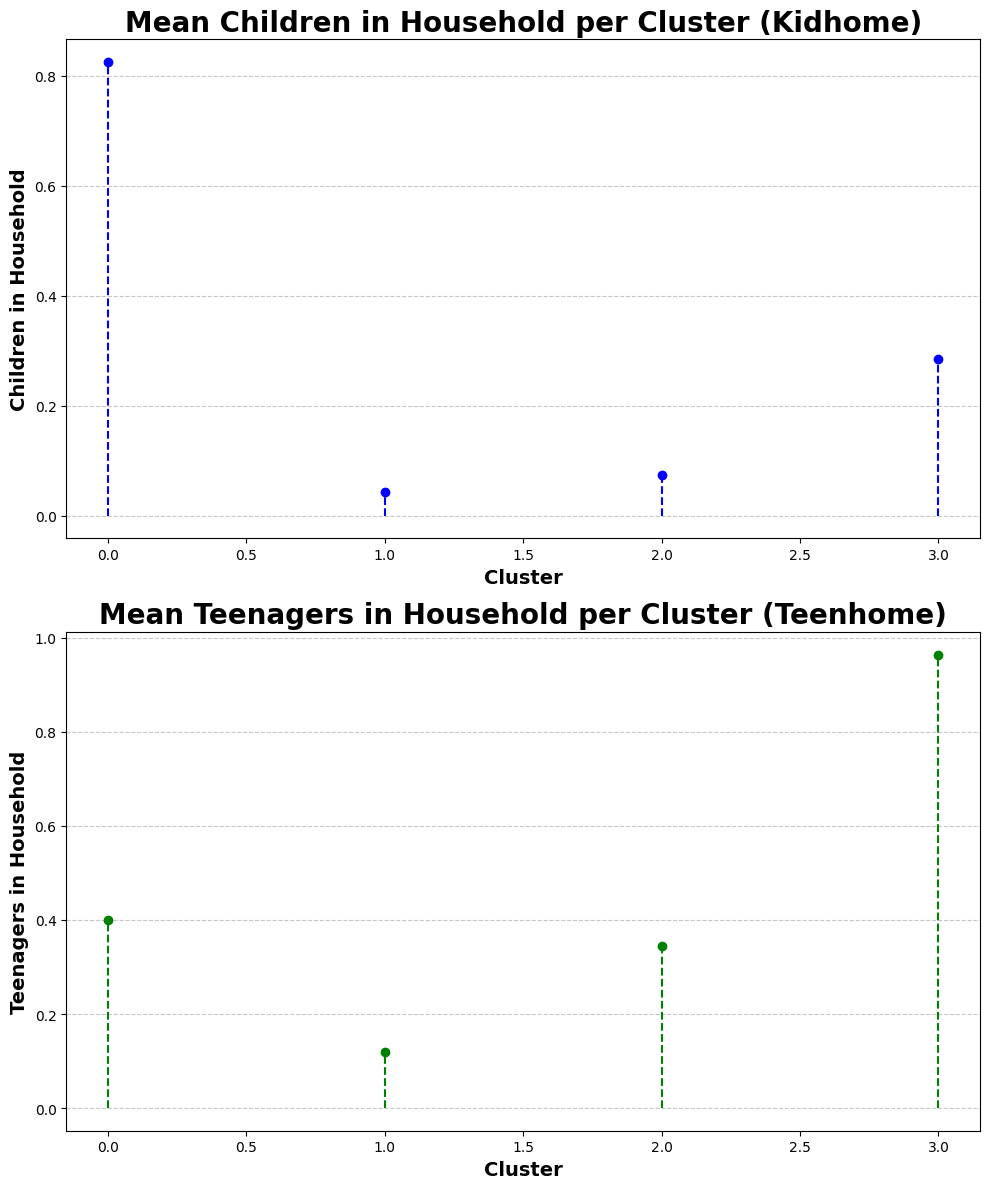

In [14]:
# Create subplots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))

# Providing a list of colors
line_colors = ['blue', 'green']

# Lollipop plot for Kidhome with custom colors and styles
kidhome_markerline, kidhome_stemlines, kidhome_baseline = axs[0].stem(
    df_cluster_analysis.index, df_cluster_analysis['Kidhome'], 
    basefmt=" ", linefmt='--', markerfmt='o'
)
# Set the colors for the stem lines and markers
plt.setp(kidhome_stemlines, color=line_colors[0])
plt.setp(kidhome_markerline, color=line_colors[0], markerfacecolor=line_colors[0])

axs[0].set_title('Mean Children in Household per Cluster (Kidhome)', fontsize=20, fontweight='bold')
axs[0].set_xlabel('Cluster', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Children in Household', fontsize=14, fontweight='bold')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Lollipop plot for Teenhome with custom colors and styles
teenhome_markerline, teenhome_stemlines, teenhome_baseline = axs[1].stem(
    df_cluster_analysis.index, df_cluster_analysis['Teenhome'], 
    basefmt=" ", linefmt='--', markerfmt='o'
)
# Set the colors for the stem lines and markers
plt.setp(teenhome_stemlines, color=line_colors[1])
plt.setp(teenhome_markerline, color=line_colors[1], markerfacecolor=line_colors[1])

axs[1].set_title('Mean Teenagers in Household per Cluster (Teenhome)', fontsize=20, fontweight='bold')
axs[1].set_xlabel('Cluster', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Teenagers in Household', fontsize=14, fontweight='bold')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()

# Show plot
plt.show()

---

The plots above show the average number of children and teens per family for each client cluster.

1) **Children in household (Kidhome)**: ***Cluster 0*** has the ***most children (0.83 per home)***, making it most young family-centered group. ***Cluster 3*** has the ***least median amount of children***, showing that young kids are underrepresented in this group.

2) **Teenagers in Household (Teenhome)**: ***Cluster 2*** has the ***greatest average number of teens (0.96 per family)***, indicating that these families are more likely to have teenagers. ***Cluster 3*** has the ***smallest proportion of teens***, with an average of just 0.12 per home.

<hr style="border: 2px dashed black;">

## Recency
Recency relates to a customer's most recent purchase, demonstrating the freshness of their engagement with the company. This cluster-wise study looks at the average recency for each cluster to better understand the levels of interaction across different client categories. The box plot depicts the distribution of recency values among the clusters, emphasizing the dispersion and central tendency of recent customer interactions.

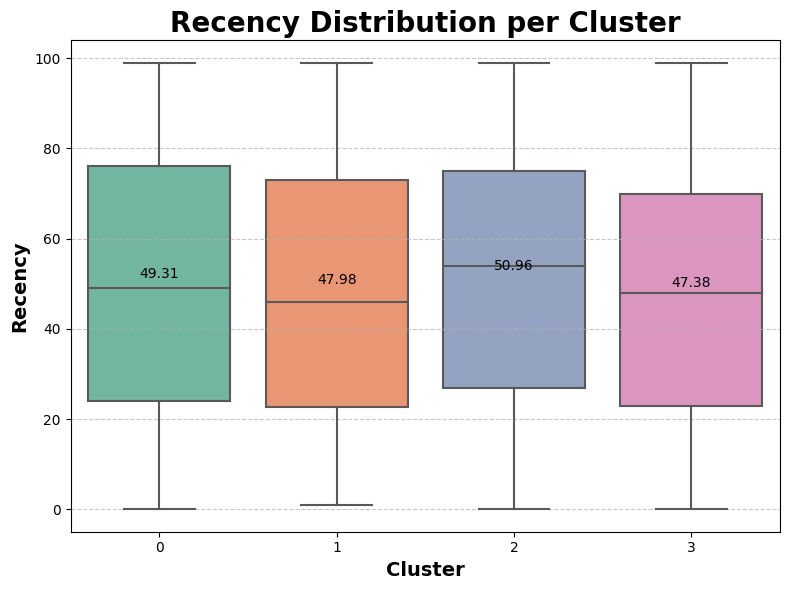

In [15]:
# Cluster-wise analysis for Recency
recency_analysis = df.groupby('Cluster')['Recency'].mean()

# Visualization: Box plot for Recency per Cluster
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='Recency', data=df, palette='Set2')
plt.title('Recency Distribution per Cluster', fontsize=20, fontweight='bold')
plt.xlabel('Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Recency', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i in range(len(recency_analysis)):
    plt.text(i, recency_analysis[i] + 2, round(recency_analysis[i], 2), ha='center', fontsize=10)

# Adjust layout for clarity
plt.tight_layout()

# Show the plot
plt.show()

---

The box plot depicts the recency distribution for each of the four clusters and provides the following essential insights:

- **Cluster 1**: This cluster has the ***greatest mean recency value, 50.96***, showing that customers in this segment purchase less frequently than in the other clusters. However, the range of values is wide, indicating that recent behavior varies within the cluster.

- **Cluster 0**: Cluster 0 has a somewhat ***lower average recency (49.27)*** than Cluster 1, but it still implies less frequent purchase activity. According to the interquartile range (IQR), the majority of customers in this category connect with the brand within 30-60 days.

- **Cluster 2 and Cluster 3**: These clusters have ***lower mean recency values (47.48 and 47.98, respectively)***, implying that customers in these groups engage with the brand more frequently than those in Clusters 0 and 1. Both clusters' IQRs exhibit a narrower distribution, indicating greater stability in customer involvement trends.


Key Features:

- **Higher Recency in Cluster 1**: Customers in Cluster 1 have ***less frequent encounters*** with the brand, as seen by greater recency values.

- **Lower Recency in Clusters 2 and 3**: These clusters exhibit ***more recent interactions***, implying that these customers are more engaged or loyal.

- **Spread in Values**: The distribution of recency values vary by cluster, with ***Cluster 1*** having the ***biggest range***, suggesting greater fluctuation in the frequency of the customer interactions.

<hr style="border: 2px dashed black;">

## Number of Deals Purchased
This research investigates the frequency with which customers in each cluster avail themselves of promotional deals by assessing the average number of deals bought. The violin plot visualizes the distribution and density of deals purchased within each cluster, illustrating variations in deal sensitivity among consumer categories.

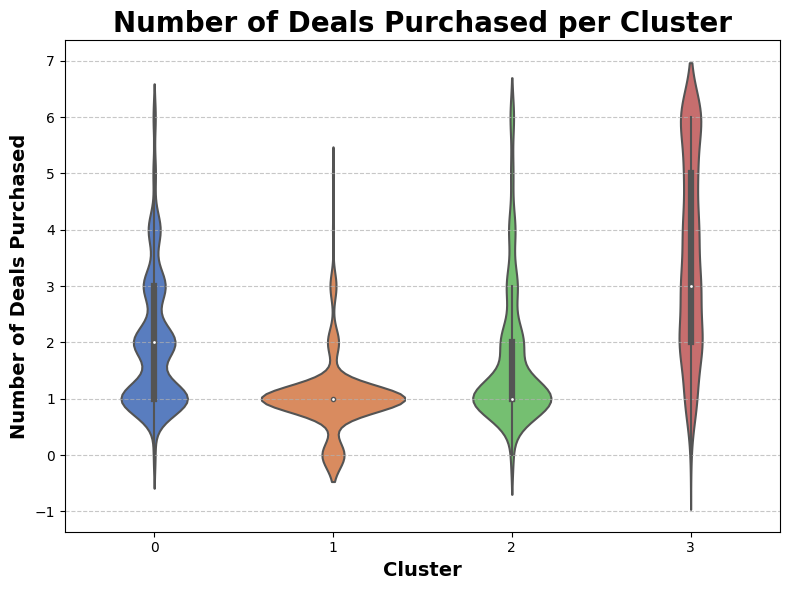

In [16]:
# Cluster-wise analysis for Number of Deals Purchased
deals_analysis = df.groupby('Cluster')['NumDealsPurchases'].mean()

# Visualization: Violin plot for Number of Deals Purchased per Cluster
plt.figure(figsize=(8, 6))
sns.violinplot(x='Cluster', y='NumDealsPurchases', data=df, palette='muted')
plt.title('Number of Deals Purchased per Cluster', fontsize=20, fontweight='bold')
plt.xlabel('Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Number of Deals Purchased', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for clarity
plt.tight_layout()

# Show the plot
plt.show()

---

The violin plot depicts the distribution of the number of deals purchased among the four clusters:

- **Cluster 2**: This cluster has the ***highest average*** and the ***most diverse*** range of deals purchased. Customers in Cluster 2 are more likely to take advantage of promotional offers, with the most bargains purchased totaling up to six. This indicates a ***high degree of participation*** in marketing campaigns in this demographic.

- **Cluster 0**: This cluster represents a ***moderate quantity*** of deals purchased, with the majority of buyers acquiring one to three deals. This implies balanced involvement with promotional offerings, however not as high as Cluster 2.

- **Cluster 1**: Customers in Cluster 1 buy ***fewer deals***, with majority of them buying anywhere from one to two deals. The distribution is narrower, indicating that fewer people participate in marketing deals than other clusters.

- **Cluster 3**: This cluster has the ***least average number of deals*** completed, with a narrow and concentrated distribution. The majority of customers in this category buy less than one deal, showing a lack of interest or participation in promotional deals.


Key Features:

- **Cluster 2's High Engagement**: The wide spread in Cluster 2 indicates that these customers are ***more likely to acquire*** a larger number of offers, demonstrating great engagement with promotions.

- **Cluster 3's Low Engagement**: Cluster 3 has the ***least interaction***, with only a few deals purchased.

- **Moderate Engagement in Cluster 0**: Customers in Cluster 0 exhibit ***moderate involvement***, with a more balanced distribution of deal purchases.


<hr style="border: 2px dashed black;">

## Web and Store Purchases
This research analyzes customers' shopping activities across clusters by assessing their average number of online and in-store purchases. The side-by-side bar plot visualizes these behaviors, allowing us to see which clusters favor online purchasing over in-store shopping and how these behaviors change among groups of customers.

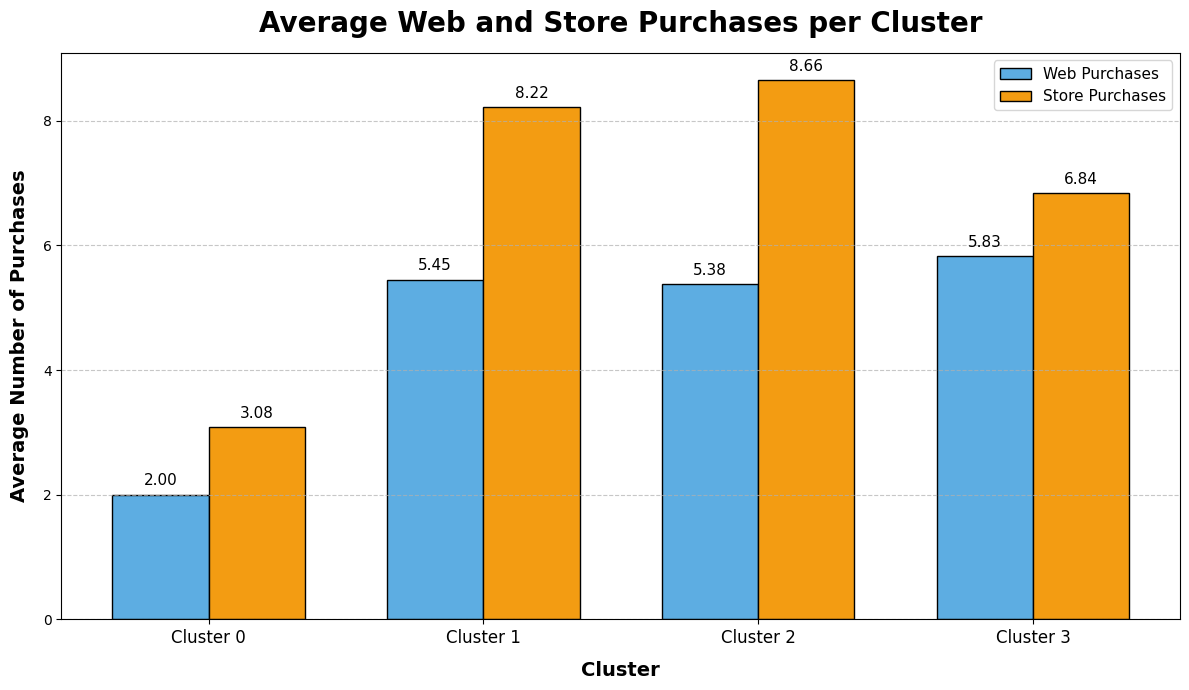

In [17]:
# Group the data by clusters and calculate the mean of Web and Store Purchases
web_purchase_analysis = df.groupby('Cluster')['NumWebPurchases'].mean()
store_purchase_analysis = df.groupby('Cluster')['NumStorePurchases'].mean()

# Create a side-by-side bar plot
bar_width = 0.35  # Width of the bars
index = np.arange(len(web_purchase_analysis))  # X-axis positions for the clusters

# Set up the plot figure and size
plt.figure(figsize=(12, 7))

# Bar for Web Purchases
bars1 = plt.bar(index, web_purchase_analysis, bar_width, label='Web Purchases', color='#5DADE2', edgecolor='black')

# Bar for Store Purchases, placed next to Web Purchases
bars2 = plt.bar(index + bar_width, store_purchase_analysis, bar_width, label='Store Purchases', color='#F39C12', edgecolor='black')

# Add labels and title
plt.xlabel('Cluster', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Average Number of Purchases', fontsize=14, fontweight='bold', labelpad=10)
plt.title('Average Web and Store Purchases per Cluster', fontsize=20, fontweight='bold', pad=15)

# Customize x-axis ticks
plt.xticks(index + bar_width / 2, ['Cluster ' + str(i) for i in web_purchase_analysis.index], fontsize=12)

# Add a grid for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a legend
plt.legend(fontsize=11)

# Add value labels on top of each bar
def add_value_labels(bars):
    """Attach a label above each bar in bars."""
    for bar in bars:
        y_value = bar.get_height()
        x_value = bar.get_x() + bar.get_width() / 2
        label = f'{y_value:.2f}'
        plt.text(x_value, y_value + 0.1, label, ha='center', va='bottom', fontsize=11)

# Apply value labels
add_value_labels(bars1)
add_value_labels(bars2)

# Final adjustments for a clean layout
plt.tight_layout()

# Display the plot
plt.show()

---

The bar plot depicts the average number of web purchases and store purchases across each of the 4 clusters:

1) **Cluster 3**:

- **Store Purchases**: Customers in Cluster 3 make the ***most store purchases***, with an ***average of 8.22***, demonstrating a significant preference for in-store purchasing.

- **Web Purchases**: Web purchases are also important in this cluster, with an ***average of 5.45***, indicating a ***balanced participation in both channels***.


2) **Cluster 1**:

- **Store Purchases**: This cluster also exhibits a ***strong tendency*** for in-store purchasing, with an ***average of 8.65*** transactions.

- **Web Purchases**: Cluster 1 had an ***average of 5.37*** web purchases, indicating a ***solid participation*** in both online and in-store channels.


3) **Cluster 2**:

- **Store Purchases**: Customers in Cluster 2 made an ***average of 6.87*** store purchases, demonstrating a ***moderate preference*** for in-store purchasing.

- **Web Purchases**: This cluster has the ***largest average of 5.84***, indicating a ***larger preference*** for online shopping compared to other clusters.


4) **Cluster 0**:

- **Store Purchases**: This cluster has the ***lowest store purchase activity***, ***averaging 3.08*** transactions.

- **Web Purchases**: Similarly, Cluster 0 had the ***fewest web purchases***, ***averaging 2.00***, indicating lower overall participation.


Key Features:

- ***Cluster 3 and Cluster 1*** had a ***strong preference for in-store purchases***, with Cluster 3 slightly more evenly split between online and in-store sales.

- ***Cluster 2*** has the ***largest average number of web purchases***, showing that this group shops more online than the other clusters.

- ***Cluster 0*** has the ***lowest purchase activity across all channels***, indicating that it may be a less engaged client demographic.

<hr style="border: 2px dashed black;">

## Marketing Campaign Responses
This investigation investigates how customers in each cluster react to different marketing strategies. The stacked bar plot depicts the acceptance rate of five marketing campaigns (Cmp1–Cmp5) for each cluster, revealing customer involvement with promotional activities. This study aids in determining which clusters are most responsive to marketing operations.

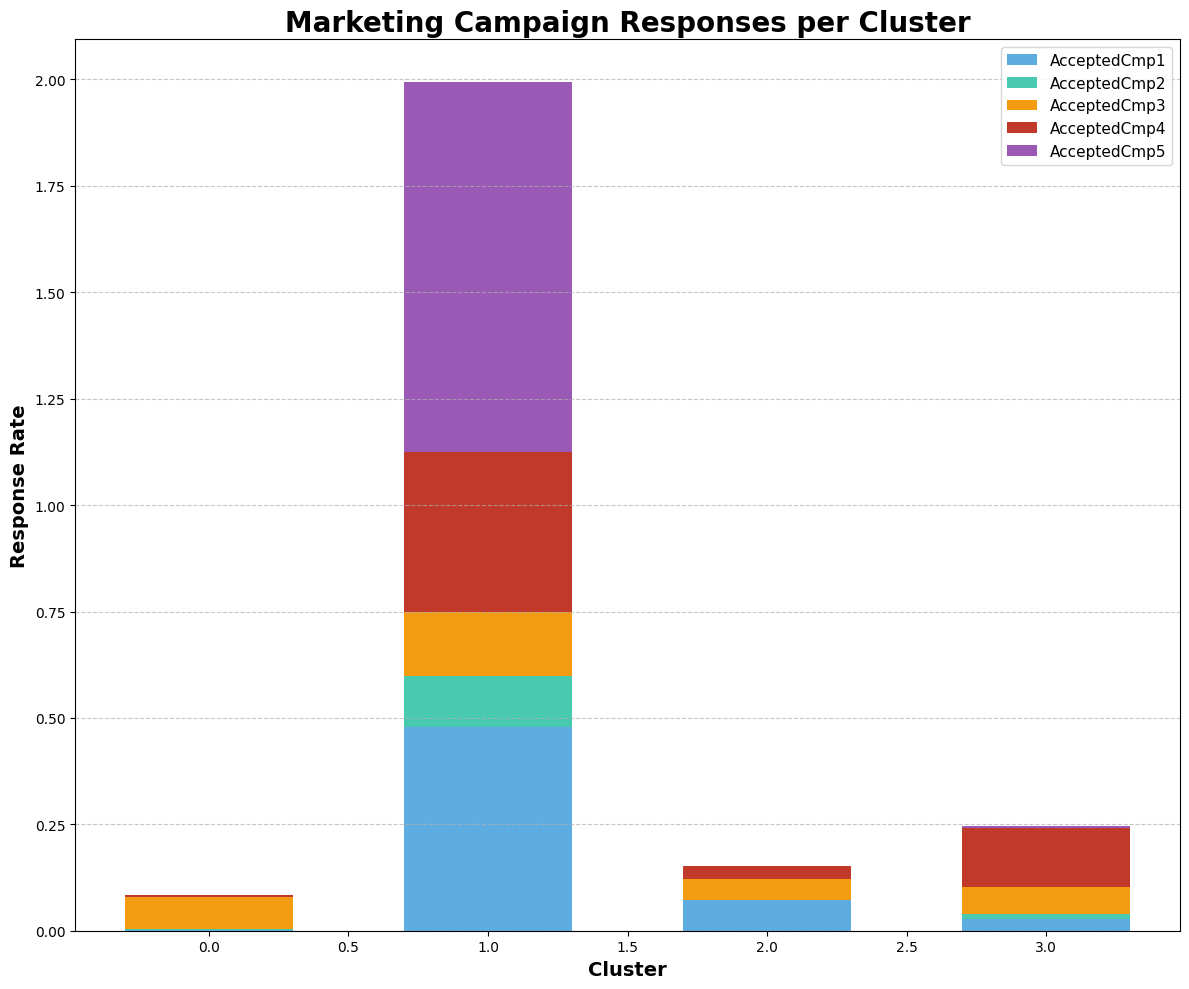

In [18]:
# Cluster-wise analysis for Marketing Campaign Responses
marketing_responses = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
marketing_analysis = df.groupby('Cluster')[marketing_responses].mean()

# Visualization: Stacked bar plot for Marketing Campaign Responses per Cluster
plt.figure(figsize=(12, 10))
bar_width = 0.6

# Colors for each marketing response
colors = ['#5DADE2', '#48C9B0', '#F39C12', '#C0392B', '#9B59B6']

# Cumulative data for stacking
bottom_data = np.zeros(len(marketing_analysis))

# Plotting each campaign response in stacked bars
for i, response in enumerate(marketing_responses):
    plt.bar(marketing_analysis.index, marketing_analysis[response], bar_width, bottom=bottom_data, color=colors[i], label=response)
    bottom_data += marketing_analysis[response]

plt.title('Marketing Campaign Responses per Cluster', fontsize=20, fontweight='bold')
plt.xlabel('Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Response Rate', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a legend
plt.legend(fontsize=11)

# Final adjustments for a clean layout
plt.tight_layout()

# Display the plot
plt.show()

The stacked bar plot depicts the average response rate for five distinct marketing efforts across the four clusters:

1) **Cluster 3**:

- This cluster has significantly ***higher response rates***, with a total response rate of ***more than 1.75***. This cluster has the ***greatest engagement rate across all five initiatives***, with particularly strong reactions to AcceptedCmp5 and AcceptedCmp1.

- ***AcceptedCmp5*** stands out as the ***most effective campaign*** in this cluster, indicating that this demographic is highly engaged and inclined to respond to marketing promotions.


2) **Cluster 2**:

- This cluster is ***moderately engaged***, with a cumulative ***response rate just around 0.25***. The responses are ***spread rather fairly across all campaigns***, with ***AcceptedCmp3*** and ***AcceptedCmp4*** showing somewhat ***greater acceptance*** percentages than the other campaigns.


3) **Cluster 1**:

- This cluster has relatively ***low participation*** in marketing activities, with a cumulative ***response rate of less than 0.25***. The participation rates in ***all campaigns are evenly distributed***, although lower than in Cluster 2.


4) **Cluster 0**:

- This cluster has the ***lowest engagement***, with very few responses to any campaign. This demographic is largely disconnected from marketing efforts with response rates ***hardly topping 0.1***.


Key Features:

- **Cluster 3’s High Engagement**: This cluster is the ***most receptive to marketing initiatives***, with AcceptedCmp5 and AcceptedCmp1 doing exceptionally well. This suggests that consumers in Cluster 3 are ***more inclined to participate*** across multiple marketing initiatives.

- **Moderate Engagement in Cluster 2**: While ***not as receptive*** as Cluster 3, Cluster 2 responds ***evenly to all campaigns***, indicating that these customers are somewhat engaged overall.

- **Low Engagement in Clusters 0 and 1**: These clusters demonstrate ***little to no interest*** in advertising campaigns, making them less susceptible to promotional tactics.


<hr style="border: 2px solid black;">

# Comparison Between Python and R

<hr style="border: 2px dashed black;">

## Elbow Method Comparison

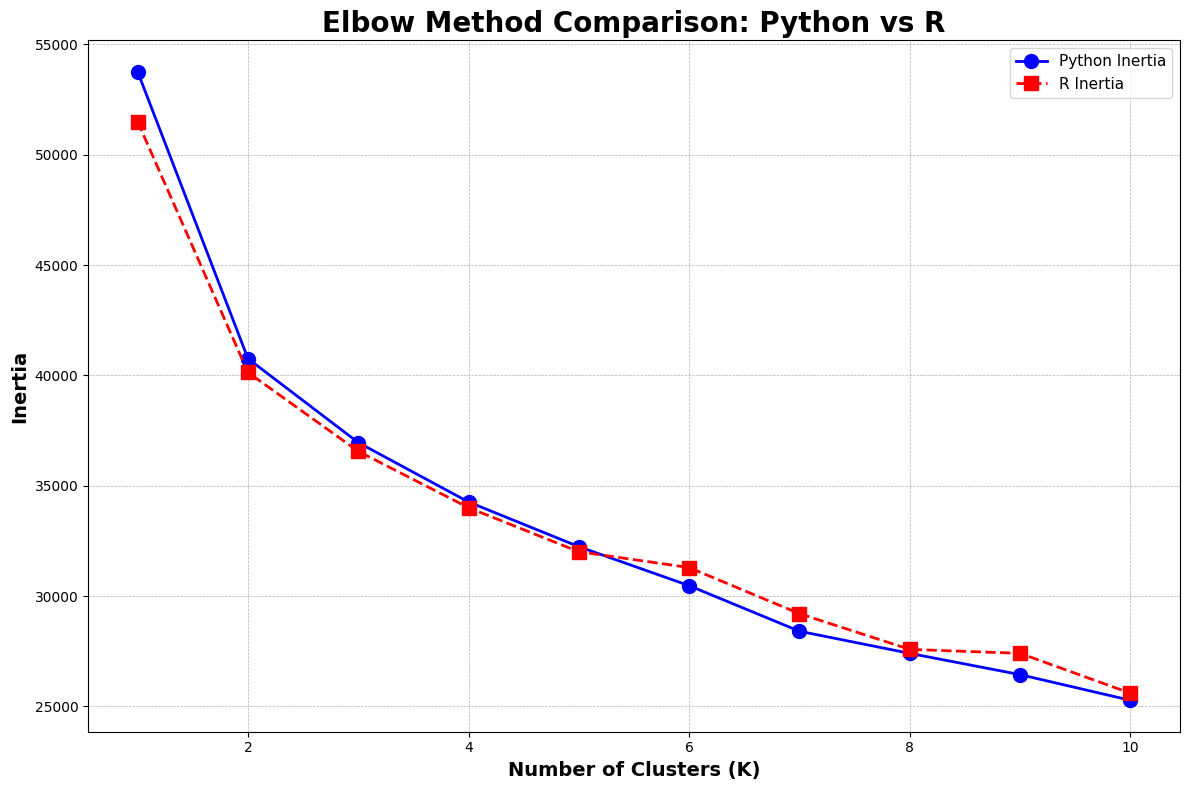

In [19]:
import matplotlib.pyplot as plt

# Data for visualization from R and Python
k_values = range(1, 11)
python_inertia = [53760.00000000001, 40759.944995770114, 36955.31627913753, 34262.86665314788, 32236.842788551887, 
                  30469.41688470551, 28405.257436586035, 27403.103104054513, 26438.9498641159, 25275.61568073161]
r_inertia = [51497.0, 40135.54, 36558.61, 34004.24, 32008.97, 31290.72, 29201.15, 27583.00, 27403.68, 25597.60]

# Create the figure and axis
plt.figure(figsize=(12, 8))

# Plotting Python and R Elbow Method results with markers and line styles
plt.plot(k_values, python_inertia, marker='o', color='blue', linestyle='-', linewidth=2, markersize=10, label='Python Inertia')
plt.plot(k_values, r_inertia, marker='s', color='red', linestyle='--', linewidth=2, markersize=10, label='R Inertia')

# Adding title and labels
plt.title('Elbow Method Comparison: Python vs R', fontsize=20, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.ylabel('Inertia', fontsize=14, fontweight='bold')

# Adding grid and legend for clarity
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', fontsize=11)

# Show the plot
plt.tight_layout()
plt.show()

<hr style="border: 2px dashed black;">

## Silhouette Score Comparison

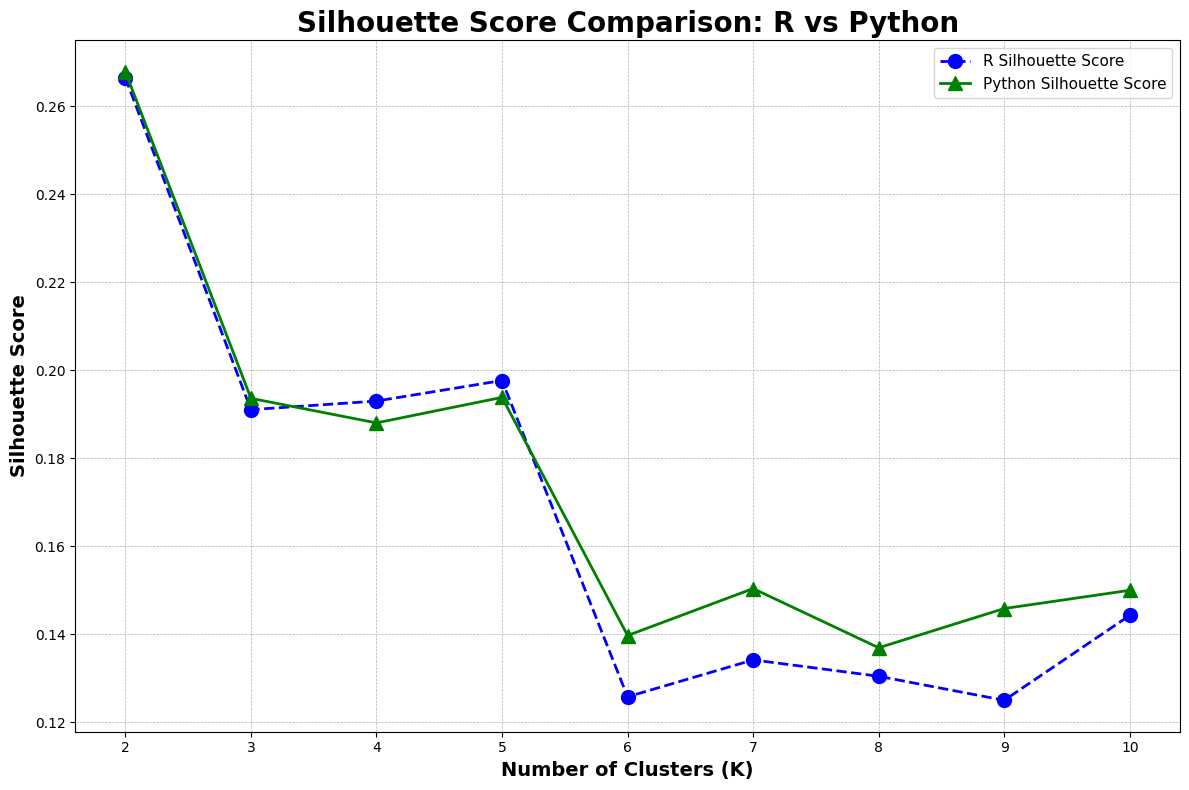

In [20]:
import matplotlib.pyplot as plt

# K values and Silhouette scores from R and Python
k_values = range(2, 11)  # K values starting from 2
silhouette_r = [0.2665154, 0.1910870, 0.1930453, 0.1977121, 0.1258211, 0.1342060, 0.1304899, 0.1250264, 0.1443311]
silhouette_python = [0.2678923382542171, 0.19366245830303422, 0.18807746418374577, 0.19388384244663875, 
                     0.13975311773320298, 0.15042300149965568, 0.13696809998541662, 0.1458830193694672, 0.15003151846702703]

# Create the figure and axis
plt.figure(figsize=(12, 8))

# Plotting the Silhouette scores for R and Python with different markers and line styles
plt.plot(k_values, silhouette_r, marker='o', color='blue', linestyle='--', linewidth=2, markersize=10, label='R Silhouette Score')
plt.plot(k_values, silhouette_python, marker='^', color='green', linestyle='-', linewidth=2, markersize=10, 
         label='Python Silhouette Score')

# Adding labels and title
plt.title('Silhouette Score Comparison: R vs Python', fontsize=20, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=14, fontweight='bold')

# Adding a grid, legend, and setting axis limits for better clarity
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(k_values)

# Show the plot
plt.tight_layout()
plt.show()

<hr style="border: 2px dashed black;">

## Davies-Bouldin Index Comparison

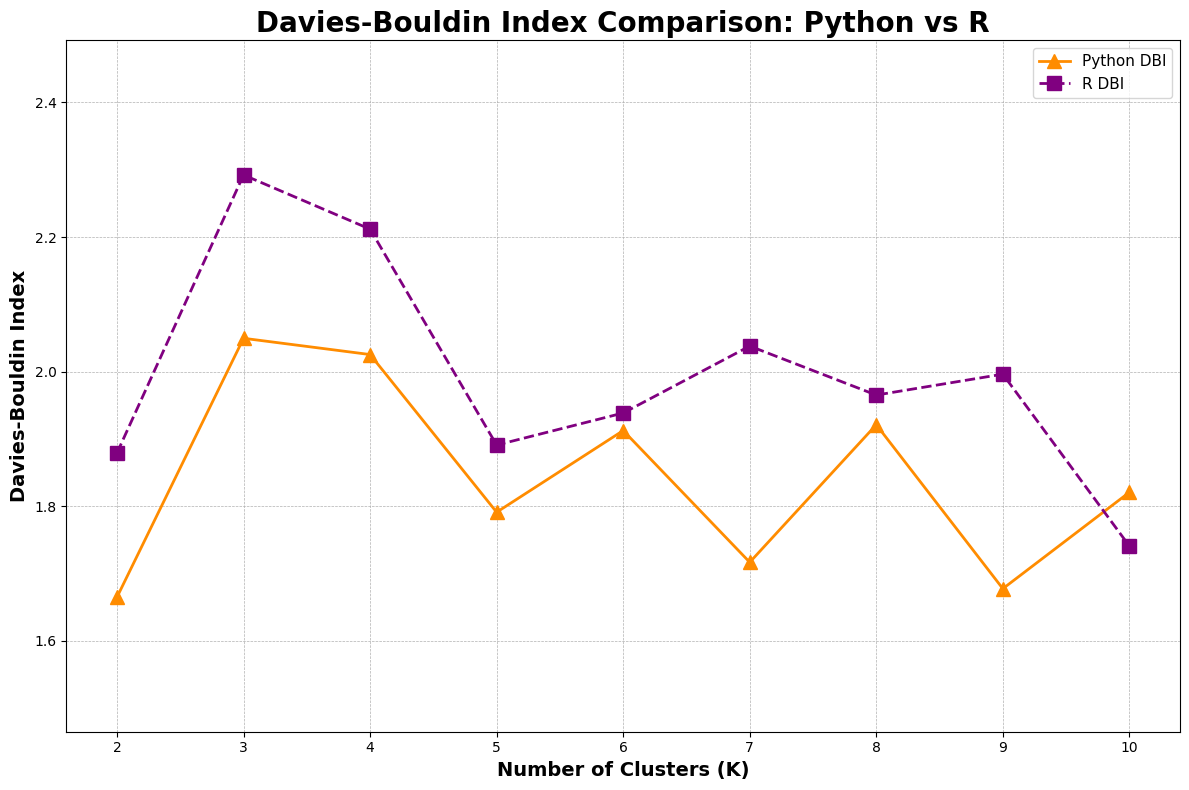

In [21]:
import matplotlib.pyplot as plt

# K values and Davies-Bouldin Index scores from R and Python
k_values = range(2, 11)  # K values starting from 2
dbi_python = [1.665194538535308, 2.0496329114959155, 2.0254557736229604, 1.7912525956258736, 
              1.9125740476214326, 1.716917083458197, 1.9212059163041195, 1.6776668945083097, 1.820897924606469]
dbi_r = [1.879397, 2.292225, 2.211743, 1.891030, 1.938655, 2.038069, 1.965290, 1.996320, 1.741009]

# Create the figure and axis
plt.figure(figsize=(12, 8))

# Plotting Davies-Bouldin Index for Python with a solid line and triangular markers
plt.plot(k_values, dbi_python, marker='^', color='darkorange', linestyle='-', linewidth=2, markersize=10, label='Python DBI')

# Plotting Davies-Bouldin Index for R with a dashed line and square markers
plt.plot(k_values, dbi_r, marker='s', color='purple', linestyle='--', linewidth=2, markersize=10, label='R DBI')

# Adding labels and title
plt.title('Davies-Bouldin Index Comparison: Python vs R', fontsize=20, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.ylabel('Davies-Bouldin Index', fontsize=14, fontweight='bold')

# Adding a grid and a legend for clarity
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', fontsize=11)

# Set the limits for better visibility
plt.ylim(min(min(dbi_python), min(dbi_r)) - 0.2, max(max(dbi_python), max(dbi_r)) + 0.2)
plt.xticks(k_values)

# Display the plot
plt.tight_layout()
plt.show()